[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jscanass/3CCBE_AI4Bioacoustics/blob/main/Notebook.ipynb)

# AI for Bioacoustics

## 3er Congreso Colombiano de Bioacústica y Ecoacústica (3CCBE)

Lunes, 28 de septiembre, 2026

Pontificia Universidad Javeriana

Bogotá, Colombia


En este cuaderno explorarás aplicaciones de audición computacional en ecología, tales como
la detección automatizada de animales y la clasificación de especies a partir de datos de sensores de audio.

## Contenido

1. [Introducción](#intro)
2. [Configuración](#conf)
3. [Visualización de sonidos de animales](#vis)
4. [Clasificando sonidos de aves en Colombia](#colombia)
5. [Detectando y agrupando señales de ecolocalización en México](#mexico)
6. [Puede un modelo de aves clasificar murciélagos?](#murcis)
7. [Conclusión](#conclusion)

## Notas

- Si ves una línea que empieza con 🖌️, significa que debes revisar o modificar algo de código, o bien responder a una pregunta. No se requiere experiencia en Python: el código ya está escrito, así que siempre puedes simplemente ejecutar las celdas y observar qué sucede.
- Las líneas que comienzan con el símbolo de la bombilla (💡) ofrecen información importante, consejos o trucos.
- Detente en cada símbolo 🛑. Haremos una pausa para comentar la sección antes de continuar.
- Las secciones marcadas como 🚀 **Explora más** son actividades opcionales para profundizar en el tema si tienes curiosidad. Puedes saltártelas sin problemas, ya que el recorrido principal no depende de ellas.

---

## 1. Introducción <a id="intro"></a>

### 1.1 Audición computacional

La audición computacional es el campo de investigación que se ocupa del análisis automático de señales de audio.
Se interrelaciona con muchos otros campos, incluidos el aprendizaje automático (*machine learning*), el procesamiento de señales y la visión por computador.

**¿Qué escucha una computadora?**

- Los archivos de audio son una secuencia de números que representan la amplitud de la onda sonora
(nivel de presión) en un momento dado.

- El número de muestras por segundo se denomina **frecuencia de muestreo** (*sampling rate*).

<img alt="audio y frecuencia de muestreo" width="600"
src="https://cdn.shopify.com/s/files/1/1169/2482/files/Sampling_Rate_Cover_image.jpg?v=1654170259"></img>

**¿Qué tareas podemos realizar con la audición computacional?**

La audición computacional se utiliza en una amplia gama de aplicaciones, entre ellas:

- Reconocimiento de voz: Siri, Alexa, Google Assistant
- Recuperación de información musical: Spotify, Shazam
- Clasificación de audio: ¿Qué suena en este audio?
- Detección de eventos sonoros: Transcripción de audio a una secuencia de eventos.

<img alt="Detección de eventos sonoros" width="400"
src="http://d33wubrfki0l68.cloudfront.net/508a62f305652e6d9af853c65ab33ae9900ff38e/17a88/images/tasks/challenge2016/task3_overview.png"></img>

> Tomado del artículo: Mesaros, A., Heittola, T., Diment, A., Elizalde, B., Shah, A., Vincent, E.,
> ... & Virtanen, T. (2017, noviembre). DCASE 2017 challenge setup: Tasks, datasets and baseline
> system. En DCASE 2017-Workshop on Detection and Classification of Acoustic Scenes and Events.

### 1.2 Recopilación de datos

Se pueden utilizar **sensores acústicos** para obtener grabaciones de campo de sonidos de animales.

Por lo general, estos sensores se instalan de forma estática en el terreno durante largos periodos de tiempo y registran
sonidos de manera continua. A esto se le denomina **monitoreo acústico pasivo**.

<img alt="monitoreo acústico pasivo" width="400"
src="https://wittmann-tours.de/wp-content/uploads/2018/06/AudioMoth.jpg"></img>

Alternativamente, las grabaciones pueden dirigirse activamente hacia una especie animal o evento sonoro específico.

<img alt="grabación activa" width="400"
src="https://s3.amazonaws.com/cdn.freshdesk.com/data/helpdesk/attachments/production/48032687175/original/xjI7Dy3Q9kaCZinr5vf4ksNxQbjK13Yv3A.jpg?1584552543"></img>

> Tomado de la publicación del blog de Macaulay Library: [Consejos para la grabación
> de sonido](https://support.ebird.org/en/support/solutions/articles/48001064298-sound-recording-tips).

### 1.3 Acústica para la ecología

El sonido en un lugar determinado es un reflejo de las especies presentes en la zona y de otros
factores ambientales.

<img alt="composición del espacio acústico" width="500"
src="https://media.springernature.com/full/springer-static/image/art%3A10.1007%2Fs12304-017-9288-5/MediaObjects/12304_2017_9288_Fig1_HTML.gif?as=webp"></img>

> Tomado del artículo: Mullet, T.C., Farina, A. & Gage, S.H. The Acoustic
> Habitat Hypothesis: An Ecoacoustics Perspective on Species Habitat Selection.
> Biosemiotics 10, 319–336 (2017). https://doi.org/10.1007/s12304-017-9288-5

Si pudiéramos vincular los sonidos con las especies o individuos que los produjeron, podríamos utilizar esta información para
estudiar y monitorear la biodiversidad de una zona.

Los sensores acústicos generan una gran cantidad de datos, y su análisis no siempre resulta sencillo.
¿Podemos recurrir a la audición computacional para que nos ayude?

En este cuaderno exploraremos la tarea de **detección de sonidos animales** y **clasificación de especies**,
empleando tanto métodos manuales como automatizados.

---

## 2. Configuración <a id="conf"></a>

### 2.1 Habilitar el entorno de ejecución con GPU

Ve a `Entorno de ejecución` -> `Cambiar tipo de entorno de ejecución` y selecciona `GPU` como acelerador de hardware.

### 2.2 Ejecutar el script de configuración

Por favor, ejecuta la celda de abajo para descargar los datos que utilizarás en este notebook, así como para instalar las dependencias faltantes.

💡 No es necesario entender el comando; simplemente descarga los datos y las herramientas del taller. El proceso puede tardar uno o dos minutos en completarse.

In [48]:
!wget -q -O - https://github.com/jscanass/3CCBE_AI4Bioacoustics/raw/refs/heads/main/setup.sh | bash

Using Python 3.13.15 environment at: /usr
Checked 1 package in 101ms
Using Python 3.13.15 environment at: /usr
Checked 1 package in 101ms
Downloading...
From (original): https://drive.google.com/uc?id=1lBvKnORB-1wUcZtac59O_fwS3JRanM-a
From (redirected): https://drive.google.com/uc?id=1lBvKnORB-1wUcZtac59O_fwS3JRanM-a&confirm=t&uuid=771bcde2-6227-4c3e-a202-29e1ec0351c2
To: /content/3ccbe_data.zip
100% 1.52G/1.52G [00:17<00:00, 86.5MB/s]
Archive:  3ccbe_data.zip
replace __MACOSX/._3ccbe_data? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [{ENTER}]
replace __MACOSX/._3ccbe_data? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [# Downloa]
replace __MACOSX/._3ccbe_data? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [d utility]
replace __MACOSX/._3ccbe_data? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [ modules]
replace __MACOSX/._3ccbe_data? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [wget http]
replace 

In [2]:
# Esta celda instala las dependencias necesarias para ejecutar el tutorial.
%pip install -q pandas matplotlib scipy scikit-learn ipywidgets "bioacoustics-model-zoo[perch]"
%pip install -q --no-cache-dir --force-reinstall "Pillow==12.3.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 180.0 MB/s eta 0:00:00


### 2.3 Importación de dependencias

Todas las dependencias necesarias para el notebook se encuentran en la celda siguiente. Por favor, ejecútala antes de nada. Si por alguna razón se reinicia el entorno de ejecución, tendrás que volver a ejecutarla.

In [49]:
# Esta celda importa las librerias y configura parámetros iniciales

from pathlib import Path
from time import perf_counter

import audio_utils
import evaluation_utils
import ipywidgets
import librosa
import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotting_utils
import seaborn as sns
import tensorflow_hub as hub
from batdetect2 import api
from IPython.display import Audio, display, clear_output
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm
from umap import UMAP

In [4]:
import utils as bioai

plt.rcParams["figure.figsize"] = (10, 5)
SEMILLA = 42
RUTA_DATASET = Path.cwd() / "3ccbe_data" / "pteroset"
PROYECTO = "MAP1"
DURACION_SEGMENTO = 10.0
REGENERAR_ETIQUETAS = False
REGENERAR_EMBEDDINGS = False
DESCARGAR_AUDIO = False  # Poner en True solo para generar embeddings desde cero

---

## 3. Visualización de sonidos de animales <a id="vis"></a>



- Aunque podemos escuchar los sonidos de una grabación, a menudo resulta más fácil visualizarlos.

- Esto es especialmente útil cuando queremos comparar sonidos de distintas grabaciones o desplazarnos
rápidamente por ellas sin necesidad de escucharlas.

- Podemos utilizar formas de onda y espectrogramas para visualizar los sonidos de una grabación.

A continuación, cargaremos un conjunto de datos de grabaciones de animales proporcionado por
[Avisoft](https://www.avisoft.com/animal-sounds/) y los visualizaremos.

In [5]:
DATA_DIR = Path.cwd() / "3ccbe_data"

In [6]:
AVISOFT_AUDIO_DIR = DATA_DIR / "avisoft" / "audio"
AVISOFT_METADATA_FILE = DATA_DIR / "avisoft" / "avisoft_metadata.csv"

In [7]:
# Cargar el dataframe de metadatos
avisoft = pd.read_csv(AVISOFT_METADATA_FILE)

In [8]:
# Imprimir las primera filas
avisoft.head()

,english_name,scientific_name,href,key,kingdom,phylum,order,family,genus,species,class,wav
0,Little Grebe,Tachybaptus ruficollis,https://www.avisoft.com/sounds/zwergta.wav,2482048,Animalia,Chordata,Podicipediformes,Podicipedidae,Tachybaptus,Tachybaptus ruficollis,Aves,tachybaptus_ruficollis.wav
1,Little Grebe,Tachybaptus ruficollis,https://www.avisoft.com/sounds/zwergta2.wav,2482048,Animalia,Chordata,Podicipediformes,Podicipedidae,Tachybaptus,Tachybaptus ruficollis,Aves,tachybaptus_ruficollis_1.wav
2,Bittern,Botaurus stellaris,https://www.avisoft.com/sounds/rohrdomm.wav,2480910,Animalia,Chordata,Pelecaniformes,Ardeidae,Botaurus,Botaurus stellaris,Aves,botaurus_stellaris.wav
3,Corncrake,Crex crex,https://www.avisoft.com/sounds/corncrak.wav,4408498,Animalia,Chordata,Gruiformes,Rallidae,Crex,Crex crex,Aves,crex_crex.wav
4,Corncrake,Crex crex,https://www.avisoft.com/sounds/corncrak2.wav,4408498,Animalia,Chordata,Gruiformes,Rallidae,Crex,Crex crex,Aves,crex_crex_1.wav


In [9]:
# seleccionar un archivo aleatorio del conjunto de datos
random_recording = avisoft.sample(n=1).iloc[0]

# leer el archivo de audio e importarlo como un array de numpy
wav, samplerate = librosa.load(AVISOFT_AUDIO_DIR / random_recording.wav, sr=None)

# Calcular la duración del audio
num_samples = len(wav)  # Number of samples taken by the recorder
duration = num_samples / samplerate

# Obtener el nombre del animal
animal_name = random_recording.english_name

print(f"File selected = {random_recording.wav}")
print(f"Samplerate = {samplerate} Hz")
print(f"Duration = {duration:.2f} s")
print(f"Species = {animal_name}")

File selected = emberiza_calandra_2.wav
Samplerate = 44100 Hz
Duration = 2.07 s
Species = Corn Bunting


Escuchemos primero el audio:

In [10]:
Audio(data=wav, rate=samplerate)

Text(0.5, 1.0, 'Forma de onda del sonido de Corn Bunting')

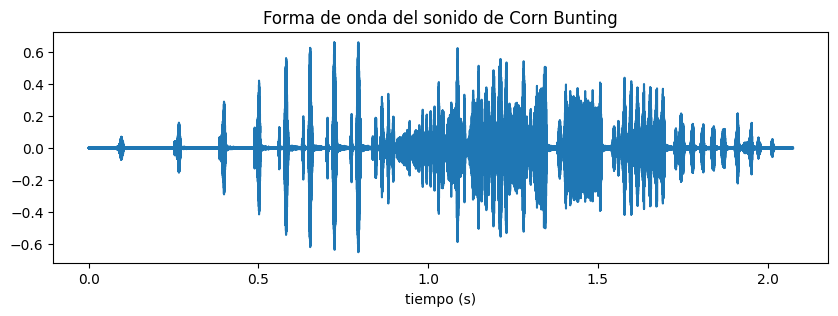

In [11]:
# Crear un plot de la forma de onda
times = np.linspace(0, duration, num_samples)
plt.figure(figsize=(10, 3))
plt.plot(times, wav)
plt.xlabel("tiempo (s)")
plt.title(f"Forma de onda del sonido de {animal_name}")

La **forma de onda** nos ofrece una representación visual de la amplitud del sonido a lo largo del tiempo.

Sin embargo, si en la grabación hay varios sonidos simultáneos, puede resultar difícil distinguir cada sonido individual.

Podemos utilizar un **espectrograma** para descomponer el sonido en **frecuencias** y visualizarlas como una imagen en dos dimensiones.

In [12]:
# Calcular el espectrograma con la transformada de Fourier de tiempo corto (STFT)
spectrogram = np.abs(librosa.stft(wav))

# La amplitud se representa mejor en escala logarítmica (decibelios)
db_spectrogram = librosa.amplitude_to_db(spectrogram, ref=np.max)

Text(0, 0.5, 'frecuencia (Hz)')

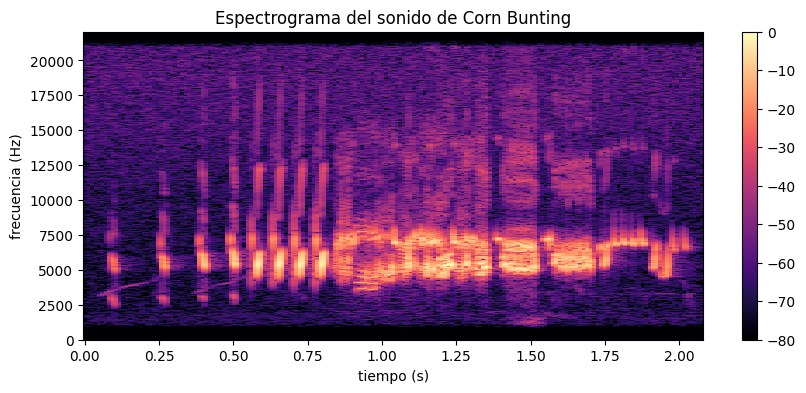

In [13]:
# Crear un plot del espectrograma
num_freq_bins, num_time_bins = db_spectrogram.shape
times = np.linspace(0, duration, num_time_bins)
freqs = np.linspace(0, samplerate / 2, num_freq_bins)

plt.figure(figsize=(10, 4))
plt.pcolormesh(times, freqs, db_spectrogram, cmap="magma")
plt.colorbar()
plt.title(f"Espectrograma del sonido de {random_recording.english_name}")
plt.xlabel("tiempo (s)")
plt.ylabel("frecuencia (Hz)")

🚀 **Más información: las matemáticas detrás de los espectrogramas.** Las dos siguientes celdas profundizan en la transformada de Fourier de tiempo reducido, el método utilizado para generar espectrogramas. Opcional: puedes pasar directamente al espectrograma interactivo que aparece más abajo.

Los sonidos producidos por los animales pueden ser muy diferentes entre sí. La transformación utilizada para
generar el espectrograma, denominada **transformada de Fourier de tiempo reducido** (STFT, por sus siglas en inglés),
resaltará distintas características del sonido en función de los parámetros empleados.

🖌️ Investiga en qué consiste la STFT y cómo sus parámetros influyen en el espectrograma. En particular, trata de
comprender el efecto del **tamaño de ventana** y del **tamaño de salto** o **solapamiento**.

La **transformada de Fourier** es un método para descomponer una serie temporal en sus frecuencias constituyentes.
[Haz clic aquí](https://www.youtube.com/watch?v=spUNpyF58BY) si te interesa una explicación intuitiva y
visual de la transformada de Fourier.

Para la **transformada de Fourier de tiempo reducido** (STFT, por sus siglas en inglés), el audio se divide en **ventanas** (o **fragmentos** o
**tramas**), que generalmente se solapan entre sí. A cada **ventana** se le aplica la transformada de Fourier, y el
resultado se añade a una matriz que registra la magnitud para cada punto de tiempo y frecuencia.

![transformada de Fourier de tiempo
reducido](https://www.mdpi.com/applsci/applsci-10-07208/article_deploy/html/images/applsci-10-07208-g001-550.jpg)

Para calcular la **STFT** de una señal, debes seleccionar una `window_length` (o `n_fft`) y un
`hop_length` (o `overlap`) para determinar cómo dividir la señal en **ventanas**.

* El `hop_size` controla la resolución temporal, o el intervalo mínimo en el que se pueden detectar
cambios en el sonido. Si `hop_length = 128`, cualquier sonido transitorio con una duración inferior a 128 muestras
será difícil de detectar.

* La `window_length` controla la resolución en frecuencia. Con una `window_length` mayor, es posible
distinguir entre frecuencias más cercanas.

* Seleccionar un valor alto o bajo para `window_length` producirá espectrogramas con muchos o pocos
contenedores (bins) de frecuencia.

* Del mismo modo, un valor alto o bajo para `hop_length` producirá espectrogramas con muchos o pocos
contenedores de tiempo.

🚀 *Fin de «Explorar más»: de vuelta al camino principal.*

En resumen: el espectrograma se construye deslizando una **ventana** breve a lo largo de la grabación y midiendo las frecuencias que contiene. Dos parámetros determinan el resultado: la **longitud de la ventana** (las ventanas más largas muestran la frecuencia con mayor detalle, pero difuminan los cambios rápidos) y la **longitud del salto** (la distancia que avanza la ventana en cada paso; los saltos más pequeños ofrecen mayor detalle temporal).

Aquí puede visualizar sonidos de diferentes especies y observar cómo estos parámetros influyen en el espectrograma.

In [14]:
# Seleccionar algunos sonidos variados del conjunto de datos avisoft
examples = [
    (row.english_name, AVISOFT_AUDIO_DIR / row.wav)
    # select one random recording per taxonomic group
    for row in avisoft.groupby("order").sample(n=1).itertuples()
]

# Crear un plot interactivo
ipywidgets.interact(
    plotting_utils.plot_waveform_with_spectrogram,
    hop_length=(32, 1024, 32),
    n_fft=(32, 2048, 32),
    window=plotting_utils.WINDOW_OPTIONS,
    file=examples,
    cmap=plotting_utils.COLORMAPS,
    speed=[
        ("x1", 1),
        ("x1.5", 1.5),
        ("x2", 2),
        ("x0.5", 0.5),
        ("x0.2", 0.2),
        ("x0.1", 0.1),
    ],
);

interactive(children=(Dropdown(description='file', options=(('Goshawk', PosixPath('/content/3ccbe_data/avisoft…

Prueba a cambiar los parámetros y observa cómo afectan a los sonidos de diferentes especies.

🖌️ ¿Te das cuenta de que ciertos parámetros funcionan bien para algunas especies, pero no para otras?

Algunas especies, como la oveja, emiten sonidos de frecuencia lentamente variable; por ello, seleccionar un `hop_length` elevado permitiría capturar su vocalización con precisión utilizando pocas muestras temporales.

Otras especies, como el zampullín chico, presentan frecuencias que varían rápidamente, por lo que un `hop_length` elevado difuminaría los matices de su canto.

Se puede optar por un `window_length` reducido si la identificación no depende de una información de frecuencia precisa. Por ejemplo, el reclamo de la abubilla consiste en una ráfaga de tres pulsos rápidos a baja frecuencia; este patrón puede distinguirse claramente incluso con una baja resolución en frecuencia.

A menudo, distintas especies emiten sonidos en bandas de frecuencia similares. En tales casos, lo ideal es seleccionar un `window_length` que proporcione suficiente resolución en frecuencia para distinguir entre reclamos parecidos.

🖌️ ¿Cómo afectan los parámetros al tiempo de cálculo y al tamaño de la imagen resultante?

* Un `window_length` mayor producirá espectrogramas más altos y aumentará el tiempo de cómputo.
* Un `hop_length` menor producirá espectrogramas más extensos y aumentará el tiempo de cómputo.

🚀 **Explora más: medición del coste de cómputo.** Las siguientes celdas miden el tiempo de cálculo del espectrograma para diversas configuraciones de parámetros. Opcional.

In [15]:
# tomar un solo archivo
species, filepath = examples[0]

print(
    f"Se generarán múltiples espectrogramas de los sonidos de {species}. Usando el archivo: {filepath.name}"
)

# cargar el audio
wav, sr = librosa.load(filepath, sr=None)

# seleccionar múltiples opciones de window_length y hop_length
window_lengths = np.arange(64, 2048, 64)
hop_lengths = np.arange(32, 1024, 32)

# crear una lista en la que almacenar los tiempos de cálculo resultantes
computation_times = []

# iterar sobre todas las opciones de window_length y hop_length
for window_length in window_lengths:
    for hop_length in hop_lengths:
        # empezar el contador
        computation_time = perf_counter()

        # compute spectrogram
        spectrogram = librosa.amplitude_to_db(
            np.abs(
                librosa.stft(
                    wav,
                    hop_length=hop_length,
                    n_fft=window_length,
                    window="hann",
                )
            ),
            ref=np.max,
        )

        # terminar el contador
        computation_time = perf_counter() - computation_time

        # almacenar el resultado en la lista computation_times
        computation_times.append(
            {
                "window_length": window_length,
                "hop_length": hop_length,
                "computation_time": computation_time,
                "spectrogram_size": spectrogram.size,
            }
        )

# convertir la lista computation_times en un dataframe de pandas
computation_times = pd.DataFrame(computation_times)

Se generarán múltiples espectrogramas de los sonidos de Goshawk. Usando el archivo: accipiter_gentilis.wav


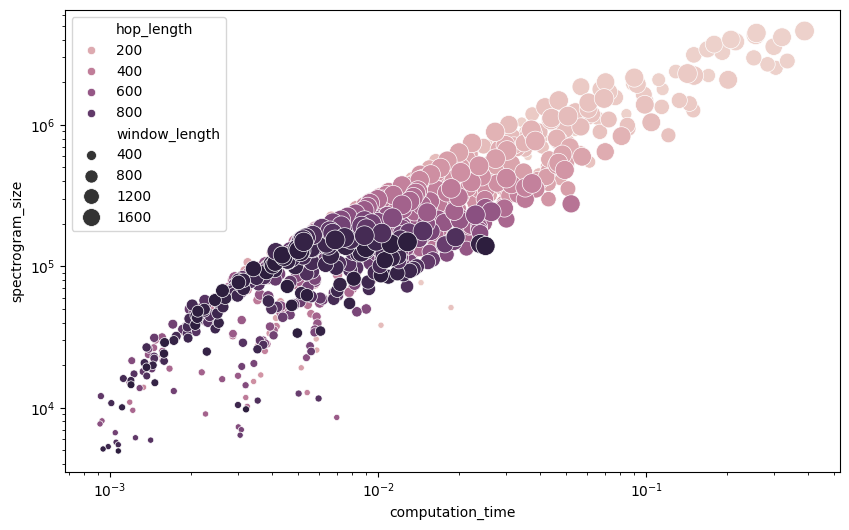

In [16]:
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=computation_times,
    x="computation_time",
    y="spectrogram_size",
    size="window_length",
    hue="hop_length",
    sizes=(20, 200),
)
ax.set_xscale("log")
ax.set_yscale("log")

Cabe señalar que, si bien el cálculo de espectrogramas suele ser rápido, las diferencias en el tiempo de procesamiento según la configuración pueden superar un orden de magnitud.
Al escalar el proceso a millones de grabaciones, un aumento de diez veces en el tiempo de cómputo cobra gran relevancia.

Del mismo modo, el tamaño de los espectrogramas resultantes puede variar hasta dos órdenes de magnitud.
Dado que los espectrogramas se utilizan a menudo como datos de entrada para modelos de aprendizaje profundo, sus dimensiones influyen directamente en el tamaño del modelo: unas entradas de mayor tamaño requieren modelos con más parámetros, lo que a su vez demanda mayores recursos computacionales y puede dificultar el entrenamiento.

🚀 *Fin de «Explorar más»: de vuelta al camino principal.*

En este caso, hemos optado por utilizar el espectrograma como representación visual del sonido. Los espectrogramas son transformaciones sumamente útiles, tanto desde una perspectiva física como biológica, ya que captan cómo se distribuye la energía entre las distintas frecuencias a lo largo del tiempo. No obstante, representan solo una de las muchas formas posibles de codificar información de audio.

Al desarrollar un modelo de aprendizaje profundo para audio (o para cualquier tipo de datos), es importante considerar formas alternativas de generar representaciones o *front-ends* (llamados así porque se sitúan al inicio de la cadena de procesamiento del aprendizaje profundo).

En el análisis de audio, por ejemplo, se puede suministrar al modelo la forma de onda original o «en bruto» (una larga secuencia de valores de amplitud) o bien utilizar otras transformaciones que se asemejan al espectrograma pero emplean una escala de frecuencias logarítmica en el eje vertical. Cada representación captura aspectos distintos de la señal y puede resultar más o menos adecuada según la tarea que se vaya a realizar.

Por lo general, este es un ámbito en el que el conocimiento especializado del dominio puede marcar la diferencia: es posible aprovechar la comprensión que se tenga de la fuente sonora para elegir una representación especialmente informativa para la tarea, o bien confiar en que el propio modelo aprenda características útiles directamente a partir de los datos originales.

**🛑 Debate en grupo**

Hagamos una pausa aquí: comentaremos estos puntos en grupo.

1. ¿Qué sonido de animal te sorprendió más? Ahora que has visto algunos, ¿podrías identificar al animal basándote únicamente en el espectrograma, sin reproducir el audio? ¿En qué pistas visuales te fijarías?
2. Las vocalizaciones de los murciélagos se sitúan mayoritariamente por encima del rango auditivo humano; al ralentizar los sonidos, se revelaron detalles que de otro modo habrían pasado inadvertidos. ¿Qué otras cosas podrían estar ocurriendo en el mundo natural totalmente fuera de la percepción humana, y qué tipo de sensor podría captarlas?
3. Imagina que dejas una grabadora funcionando durante un mes fuera de este edificio o en una selva tropical. ¿Qué se habría grabado realmente? ¿Cómo encontrarías esos diez segundos que te interesan entre 700 horas de audio?

## 4 .Clasificación de aves con Perch 2 en PteroSet <a id="colombia"></a>

Este tutorial usa el proyecto `MAP1` de [PteroSet](https://zenodo.org/records/21829388), un conjunto de monitoreo acústico pasivo con anotaciones de especies.

El tutorial:

1. descarga y valida los archivos necesarios;
2. convierte anotaciones fuertes en ventanas multietiqueta de 5 segundos;
3. prueba qué ocurre al usar directamente el clasificador original de Perch 2;
4. genera o reutiliza embeddings de Perch 2;
5. separa entrenamiento y prueba por grabación;
6. compara clasificadores superficiales;
7. selecciona un umbral y explora errores.

### 4.1 Preparación del entorno y descarga

El dataset completo consta de 5 proyectos. Este tutorial usa `MAP1`, el proyecto con menos audios pero a la vez el más retador debido al sobrelapamiento de sus anotaciones. PteroSet contiene WAV *time-lapse*. En `MAP1`, los segmentos duran 10 s y avanzan cada 10 s, sin solapamiento. El tutorial conserva esa geometría y nunca reparte ventanas de una misma grabación entre entrenamiento y prueba.

Las etiquetas y los clasificadores pueden ejecutarse reutilizando los CSV de etiquetas y embeddings, sin conservar todos los WAV. Con `DESCARGAR_AUDIO = False`, el notebook no vuelve a descargar archivos eliminados y los exploradores muestran únicamente ejemplos cuyos WAV continúan disponibles. Todos los WAV solo son necesarios si se regeneran los embeddings.

In [17]:
# Esta celda define el dataset de acuerdo a los archivos presentes en el directorio de datos
dataset = bioai.PteroSet(
    raiz=RUTA_DATASET,
    proyecto=PROYECTO,
    duracion_segmento=DURACION_SEGMENTO,
    descargar_audio=DESCARGAR_AUDIO,
)

# Alternativa para cargar los datos
raiz_datos = Path.cwd() / "3ccbe_data/pteroset"
ruta_etiquetas = Path.cwd() / "3ccbe_data/pteroset/map1_paso10_etiquetas_5s.csv"
ruta_embeddings = Path.cwd() / "3ccbe_data/pteroset/map1_paso10_perch2_embeddings_5s.csv"

print(f"Datos en: {raiz_datos}")
print(f"Etiquetas en: {ruta_etiquetas}")
print(f"Embeddings en: {ruta_embeddings}")
print(f"WAV disponibles para visualización: {len(dataset.wav_por_nombre)}")

Datos en: /content/3ccbe_data/pteroset
Etiquetas en: /content/3ccbe_data/pteroset/map1_paso10_etiquetas_5s.csv
Embeddings en: /content/3ccbe_data/pteroset/map1_paso10_perch2_embeddings_5s.csv
WAV disponibles para visualización: 5


### 4.2 De anotaciones fuertes a etiquetas multihot de 5 segundos

`annotations_species.json` sigue un esquema inspirado en COCO:

- `sounds` describe cada WAV y vincula `id`, archivo, proyecto y duración;
- `categories` relaciona identificadores con códigos y nombres científicos;
- `annotations` contiene `sound_id`, `category`, `t_min`, `t_max`, `f_min` y `f_max`.

Cada grabación de `MAP1` se divide primero en segmentos consecutivos de 10 s y después en dos ventanas de 5 s, sin solapamiento. Una especie se marca como presente cuando su evento tiene solapamiento temporal positivo con la ventana. La frecuencia no se usa para la etiqueta, pero sus límites siguen disponibles en el JSON para tareas de localización tiempo–frecuencia.

In [18]:
etiquetas = dataset.cargar_etiquetas(regenerar=REGENERAR_ETIQUETAS)

print(f"Proyecto: {PROYECTO}")
print(
    f"Dimensiones: {etiquetas.shape[0]} ventanas × "
    f"{etiquetas.shape[1]} especies"
)
etiquetas.head()

Se reutilizó /content/3ccbe_data/pteroset/map1_paso10_etiquetas_5s.csv
Proyecto: MAP1
Dimensiones: 4416 ventanas × 72 especies


AMAOCH  ANTNIG  ARACAJ  \
file                          start_time end_time                           
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0            0       0       0   
                              5.0        10.0           0       0       0   
                              10.0       15.0           0       0       0   
                              15.0       20.0           0       0       0   
                              20.0       25.0           0       0       0   

                                                   ARAGUA  ATAPIL  ATRPIL  \
file                          start_time end_time                           
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0            0       0       0   
                              5.0        10.0           0       0       0   
                              10.0       15.0           0       0       0   
                              15.0       20.0           0       0       0   
                              20.0       25.0           0       0       0   

                                                   BROJUG  CAMGRI  CAMNUC  \
file                          start_time end_time                           
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0            0       0       0   
                              5.0        10.0           0       0       0   
                              10.0       15.0           0       0       0   
                              15.0       20.0           0       0       0   
                              20.0       25.0           0       0       0   

                                                   CERCIN  ...  TAPNAE  \
file                          start_time end_time          ...           
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0            0  ...       0   
                              5.0        10.0           0  ...       0   
                              10.0       15.0           0  ...       0   
                              15.0       20.0           0  ...       0   
                              20.0       25.0           0  ...       0   

                                                   THREPI  THRPAL  TOLFLA  \
file                          start_time end_time                           
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0            0       0       0   
                              5.0        10.0           0       0       0   
                              10.0       15.0           0       0       0   
                              15.0       20.0           0       0       0   
                              20.0       25.0           0       0       0   

                                                   TROAED  TYRANN_SP1  TYRMEL  \
file                          start_time end_time                               
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0            0           0       0   
                              5.0        10.0           0           0       0   
                              10.0       15.0           0           0       0   
                              15.0       20.0           0           0       0   
                              20.0       25.0           0           0       0   

                                                   VANCHI  VOLJAC  ZENAUR  
file                          start_time end_time                          
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0            0       0       0  
                              5.0        10.0           0       0       0  
                              10.0       15.0           0       0       0  
                              15.0       20.0           0       0       0  
                              20.0       25.0           0       0       0  

[5 rows x 72 columns]

### 4.3 ¿Podemos usar directamente el clasificador de Perch?

Perch 2 ya incluye un clasificador entrenado para miles de especies. Si una clase de PteroSet forma parte de ese vocabulario, podemos consultar directamente su puntaje sin entrenar otro clasificador. Si no está incluida, el modelo no tiene una salida asociada a ella, aunque sus embeddings todavía pueden contener información útil para aprenderla.

El explorador cruza los nombres científicos de ambas taxonomías. Selecciona una clase incluida y otra ausente para comparar ambos casos. Para las clases incluidas también ejecuta el clasificador original y muestra la posición de la especie esperada entre sus predicciones; estar en el vocabulario hace posible la predicción, pero no garantiza que sea correcta.

In [19]:
!pip uninstall -y pillow
!pip install --no-cache-dir --force-reinstall "pillow==11.3.0"

Found existing installation: pillow 12.3.0
Uninstalling pillow-12.3.0:
  Successfully uninstalled pillow-12.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 99.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opensoundscape 0.13.2 requires pillow>=12.2.0, but you have pillow 11.3.0 which is incompatible.


In [20]:
#VERIFICACIÓN DE LA CORRECCIÓN
import PIL
print(PIL.__version__)

from PIL import Image, ImageDraw, ImageFont
print("Pillow OK")

11.3.0
Pillow OK


In [21]:
demo_clasificador_perch = bioai.crear_demo_clasificador_directo_perch(
    dataset,
    etiquetas,
)
display(demo_clasificador_perch)

Cargando Perch 2 y su vocabulario de clases...
Perch incluye 67 de las 72 clases de PteroSet.


,Código PteroSet,Clase en PteroSet,¿Está en Perch?,Ejemplos disponibles
0,AMAOCH,Amazona ochrocephala,True,0
1,ANTNIG,Anthracothorax nigricollis,True,8
2,ARACAJ,Aramides cajaneus,True,3
3,ARAGUA,Aramus guarauna,True,2
4,ATAPIL,Atalotriccus pilaris,True,0
...,...,...,...,...
67,TYRANN_SP1,Tyrannidae sp 1,False,0
68,TYRMEL,Tyrannus melancholicus,True,13
69,VANCHI,Vanellus chilensis,True,1
70,VOLJAC,Volatinia jacarina,True,4


#### Explorar las etiquetas

El conteo siguiente indica cuántas ventanas de 5 segundos contienen cada especie. Un fuerte desbalance entre clases es habitual en bioacústica y es una razón para preferir AP frente a accuracy como métrica principal.

,ventanas_positivas
especie,
Pitangus sulphuratus,281
Atalotriccus pilaris,157
Tolmomyias flaviventris,117
Leptotila verreauxi,114
Thraupis episcopus,93
Tyrannus melancholicus,92
Columbina squammata,84
Patagioenas cayennensis,83
Brotogeris jugularis,82


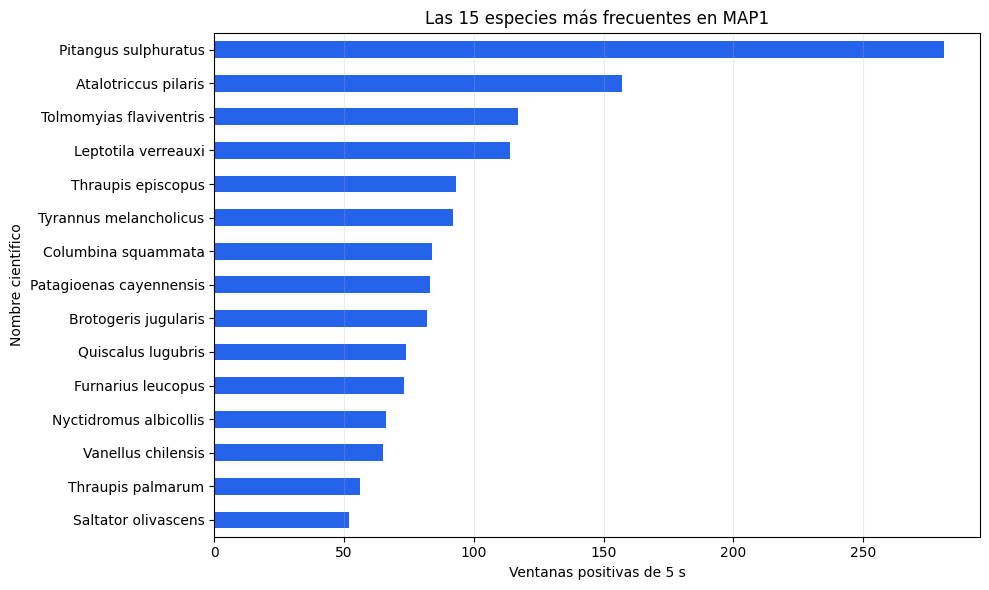

Ventanas sin etiqueta: 2910
Ventanas con más de una etiqueta: 564


In [22]:
frecuencia_clases = bioai.resumir_etiquetas(
    etiquetas,
    PROYECTO,
    dataset.taxonomia,
)
explorador_etiquetas = bioai.crear_explorador_etiquetas(
    dataset,
    etiquetas,
    frecuencia_clases,
)

El siguientevexplorador permite elegir una especie y recorrer sus ventanas positivas. Para cada ejemplo muestra:

- el reproductor del fragmento de 5 segundos;
- la forma de onda;
- el espectrograma hasta 24 kHz;
- las cajas tiempo–frecuencia de la especie seleccionada; y
- todas las especies etiquetadas simultáneamente en esa ventana.

In [23]:
display(explorador_etiquetas)

### 4.4 Generar o reutilizar embeddings de Perch 2

Perch 2 resume cada ventana de audio en un vector numérico sin usar las etiquetas para ajustar su red. La indexación `(file, start_time, end_time)` conecta cada embedding con su fila multihot.

La primera ejecución genera los embeddings y los guarda en CSV; las siguientes reutilizan el archivo. La operación puede tardar según el número de ventanas y el hardware disponible.

In [24]:
embeddings = dataset.cargar_embeddings(
    etiquetas,
    regenerar=REGENERAR_EMBEDDINGS,
)

print(
    f"Dimensiones: {embeddings.shape[0]} ventanas × "
    f"{embeddings.shape[1]} características"
)
embeddings.head(2)

Se reutilizó /content/3ccbe_data/pteroset/map1_paso10_perch2_embeddings_5s.csv
Dimensiones: 4416 ventanas × 1536 características


0         1  \
file                          start_time end_time                       
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0      -0.026097  0.214491   
                              5.0        10.0     -0.014954  0.166548   

                                                          2         3  \
file                          start_time end_time                       
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0      -0.063331  0.030382   
                              5.0        10.0     -0.057485  0.021182   

                                                          4         5  \
file                          start_time end_time                       
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0       0.106293 -0.026325   
                              5.0        10.0      0.090911  0.006493   

                                                          6         7  \
file                          start_time end_time                       
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0      -0.139744 -0.130139   
                              5.0        10.0     -0.085028 -0.140989   

                                                          8         9  ...  \
file                          start_time end_time                      ...   
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0      -0.000173 -0.143070  ...   
                              5.0        10.0     -0.009805 -0.147895  ...   

                                                       1526      1527  \
file                          start_time end_time                       
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0      -0.047521  0.009047   
                              5.0        10.0     -0.039772  0.100536   

                                                       1528      1529  \
file                          start_time end_time                       
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0       0.005679 -0.056961   
                              5.0        10.0     -0.007058 -0.036640   

                                                       1530      1531  \
file                          start_time end_time                       
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0      -0.039841 -0.160233   
                              5.0        10.0     -0.037855 -0.160661   

                                                      1532      1533  \
file                          start_time end_time                      
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0      -0.11585  0.069004   
                              5.0        10.0     -0.09805  0.067960   

                                                       1534      1535  
file                          start_time end_time                      
MAP1/P6-G026_06-05_tlapse.wav 0.0        5.0       0.329410 -0.135445  
                              5.0        10.0      0.384354 -0.156201  

[2 rows x 1536 columns]

### 4.5 Verificar y alinear etiquetas y embeddings

Ambos archivos deben tener igual número de filas, así como el orden y las tres claves del índice también deben coincidir. La intersección explícita evita asociar un sonido con la etiqueta de otra ventana.

In [25]:
etiquetas, embeddings = bioai.alinear_datos(etiquetas, embeddings)
print(f"Conjunto alineado: {len(etiquetas)} ventanas")

Conjunto alineado: 4416 ventanas


### 4.6 Separación por grabación

Ventanas del mismo WAV comparten ambiente, equipo, individuos y ruido. Repartirlas aleatoriamente permitiría que fragmentos muy relacionados aparecieran en entrenamiento y prueba.

Usamos `GroupShuffleSplit` para reservar el 25 % de las grabaciones completas. Se prueban semillas deterministas hasta obtener positivos y negativos de la especie objetivo en ambos conjuntos. Este criterio evita métricas indefinidas sin mezclar ventanas de un mismo archivo.

In [26]:
ESPECIE = "PITSUL"
particion = bioai.separar_por_grabacion(
    etiquetas,
    embeddings,
    especie=ESPECIE,
    semilla=SEMILLA,
)

display(
    particion.grabaciones.value_counts()
    .rename("ventanas")
    .to_frame()
    .head(10)
)
print(
    f"Entrenamiento: {len(particion.embeddings_entrenamiento)} ventanas de "
    f"{particion.etiquetas_entrenamiento.index.get_level_values('file').nunique()} "
    "grabaciones"
)
print(
    f"Prueba: {len(particion.embeddings_prueba)} ventanas de "
    f"{particion.etiquetas_prueba.index.get_level_values('file').nunique()} "
    "grabaciones"
)

,ventanas
grabacion,
P5-G022_04-13_tlapse.wav,96
P5-G022_04-14_tlapse.wav,96
P5-G022_04-15_tlapse.wav,96
P5-G022_04-16_tlapse.wav,96
P5-G022_04-17_tlapse.wav,96
P5-G022_04-18_tlapse.wav,96
P5-G022_06-01_tlapse.wav,96
P5-G022_06-02_tlapse.wav,96
P5-G022_06-03_tlapse.wav,96


Entrenamiento: 3264 ventanas de 34 grabaciones
Prueba: 1152 ventanas de 12 grabaciones


#### Especie objetivo

Entrenaremos clasificadores binarios para `PITSUL` (*Pitangus sulphuratus*), la especie con más eventos anotados en `MAP1`. `species.csv` permite traducir el código normalizado al nombre científico.

In [27]:
nombre_cientifico = dataset.taxonomia.set_index("code").loc[ESPECIE, "species"]
print(f"Objetivo: {ESPECIE} — {nombre_cientifico}")

(
    X_entrenamiento,
    X_prueba,
    y_entrenamiento,
    y_prueba,
) = particion.datos_binarios(ESPECIE)

display(bioai.resumen_clases(y_entrenamiento, y_prueba))

Objetivo: PITSUL — Pitangus sulphuratus


,entrenamiento,prueba
PITSUL,,
ausente,3059,1076
presente,205,76


### 4.7 Comparar clasificadores superficiales

Comparamos modelos con supuestos distintos. Los modelos sensibles a escala se incluyen en una tubería con `StandardScaler`, ajustado **solo con entrenamiento**.

Para AP y ROC AUC no usamos clases predichas (`0/1`). Usamos un puntaje continuo obtenido mediante:

- `predict_proba(... )[:, clase_positiva]`, cuando existe; o
- `decision_function(...)`, en modelos como algunas máquinas de vectores de soporte.

Esto permite ordenar ejemplos desde menor hasta mayor confianza y evaluar todos los umbrales posibles.

In [28]:
modelos = bioai.crear_modelos(semilla=SEMILLA)
list(modelos)

['Regresión logística',
 'SVM lineal',
 'SVM RBF',
 '3 vecinos más cercanos',
 'Bosque aleatorio',
 'Naive Bayes gaussiano',
 'SGD logístico']

In [29]:
comparacion = bioai.comparar_modelos(
    modelos,
    X_entrenamiento,
    y_entrenamiento,
    X_prueba,
    y_prueba,
)

tabla_resultados = comparacion.tabla
tabla_resultados.style.format("{:.3f}").background_gradient(
    subset=["AP prueba", "ROC AUC prueba"],
    cmap="YlGn",
)

,AP entrenamiento,AP prueba,ROC AUC entrenamiento,ROC AUC prueba,segundos de ajuste
modelo,,,,,
SVM RBF,0.981,0.774,0.999,0.959,5.801
Bosque aleatorio,0.990,0.725,0.999,0.955,19.176
Regresión logística,1.000,0.659,1.000,0.896,0.975
SGD logístico,0.931,0.613,0.998,0.903,0.367
SVM lineal,1.000,0.612,1.000,0.894,2.390
3 vecinos más cercanos,0.864,0.549,0.992,0.868,0.142
Naive Bayes gaussiano,0.407,0.456,0.940,0.928,0.112


#### Cómo interpretar las métricas

- **AP (precisión promedio):** resume la curva precisión–exhaustividad. Es especialmente útil cuando la clase positiva es rara.
- **ROC AUC:** probabilidad de asignar mayor puntaje a un positivo que a un negativo. `0.5` equivale a orden aleatorio y `1.0` a separación perfecta.
- Una brecha grande entre entrenamiento y prueba sugiere sobreajuste o un cambio acústico entre grabaciones.

No elijas un modelo solo por tiempo de entrenamiento ni por el resultado de entrenamiento. La comparación principal debe hacerse sobre grabaciones no observadas.

Mejor modelo según AP de prueba: SVM RBF


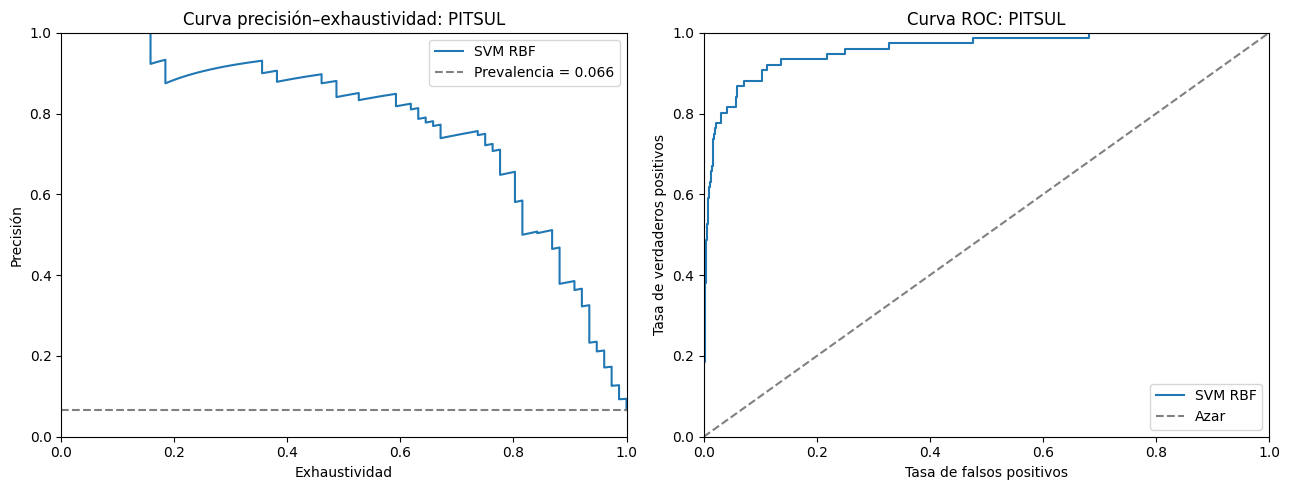

In [30]:
mejor_modelo = comparacion.mejor_modelo
mejor_puntaje = comparacion.mejor_puntaje

bioai.graficar_curvas(
    y_prueba,
    mejor_puntaje,
    mejor_modelo,
    ESPECIE,
)
print(f"Mejor modelo según AP de prueba: {mejor_modelo}")

### 4.8 Umbral de decisión y reporte operativo

AP y ROC AUC evalúan el **ranking continuo** y no requieren fijar un umbral. Para una decisión operativa sí debemos elegir uno. El ejemplo siguiente usa el umbral que maximiza F1 en la grabación de prueba **solo con fines didácticos**.

El umbral puede ser negativo cuando el mejor clasificador produce un puntaje mediante `decision_function`, como los SVM. Ese puntaje es una distancia con signo respecto a la frontera del modelo, no una probabilidad: valores mayores indican más evidencia de presencia, pero no están limitados al intervalo de 0 a 1. Un umbral negativo simplemente hace la decisión más sensible que la frontera predeterminada de cero.

En un proyecto real, el umbral debe elegirse con un conjunto de validación separado; después se reporta una única evaluación final sobre prueba. Elegir el umbral sobre prueba hace optimista el reporte de clases.

In [31]:
umbral_didactico, prediccion_binaria, reporte = bioai.seleccionar_umbral(
    y_prueba,
    mejor_puntaje,
)

print(f"Umbral didáctico: {umbral_didactico:.4f}")
print(reporte)

Umbral didáctico: -0.3656
              precision    recall  f1-score   support

     ausente      0.982     0.982     0.982      1076
    presente      0.750     0.750     0.750        76

    accuracy                          0.967      1152
   macro avg      0.866     0.866     0.866      1152
weighted avg      0.967     0.967     0.967      1152



### 4.9 Explorar falsos positivos y falsos negativos

Los errores ayudan a reconocer confusiones acústicas, anotaciones incompletas y cambios de dominio. El visualizador ordena los falsos positivos desde el puntaje más alto y los falsos negativos desde el puntaje más bajo, es decir, muestra primero los errores en los que el modelo fue más categórico.

Para cada caso se presentan el audio, el puntaje continuo, el umbral, las etiquetas reales, la forma de onda, el espectrograma y todos los eventos anotados en la ventana.

In [32]:
resumen_errores, explorador_errores = bioai.crear_explorador_errores(
    dataset,
    particion.etiquetas_prueba,
    y_prueba,
    prediccion_binaria,
    mejor_puntaje,
    ESPECIE,
    umbral_didactico,
)

display(resumen_errores.to_frame())
display(explorador_errores)

,ventanas
Falso positivo,19
Falso negativo,19


🚀 **Explora más**

1. Repite el análisis con otro proyecto de PteroSet y compara el cambio de dominio geográfico o temporal.
2. Cambia la especie objetivo usando `species.csv` y observa cómo la prevalencia afecta AP y ROC AUC.
3. Compara los errores más categóricos con casos cercanos al umbral y describe sus diferencias acústicas.

## 5: Detectando señales de ecolocalización en México <a id="mexico"></a>

- La mayoría de las veces, no nos interesan todos los sonidos de una grabación, sino únicamente los sonidos
de una especie animal específica.

- Los sensores acústicos registran indiscriminadamente todos los sonidos del entorno, incluidos los de
animales, el viento, la lluvia, etc. Aunque algunos dispositivos de grabación pueden activarse mediante un sonido específico,
esto no siempre ocurre así.

- El monitoreo acústico pasivo genera muchas horas de grabaciones, lo que dificulta la identificación y
el análisis de los sonidos de interés.


Aunque no están tan desarrolladas como en el campo de la **visión por computadora**, existen herramientas para **detectar automáticamente sonidos de animales** en las grabaciones. Aquí exploraremos algunas de ellas.

Como cabe imaginar, no es fácil anotar manualmente todos los sonidos relevantes de una grabación. Observa esta grabación.

In [33]:
DATA_DIR = Path.cwd() / "3ccbe_data"

YUCATAN_METADATA = DATA_DIR / "yucatan" / "yucatan_metadata.csv"

YUCATAN_AUDIO_DIR = DATA_DIR / "yucatan" / "audio"

# Cargar metadata del conjunto de grabaciones de murciélagos de la península de Yucatán
yucatan = pd.read_csv(YUCATAN_METADATA)

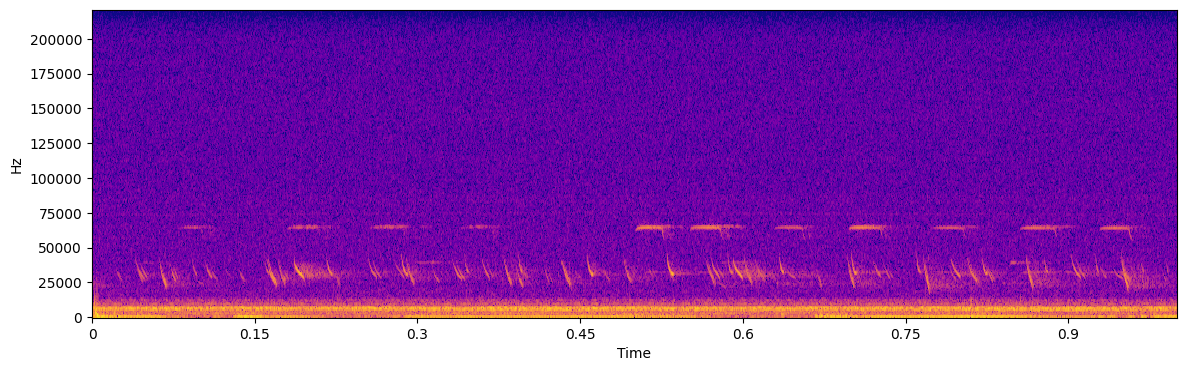

In [34]:
crowded_recording = YUCATAN_AUDIO_DIR / yucatan.id[1017]

plotting_utils.plot_spectrogram(
    crowded_recording, hop_length=128, n_fft=512, figsize=(14, 4)
)

En esta grabación hay muchas vocalizaciones de murciélagos, y anotarlas todas llevaría muchísimo tiempo.

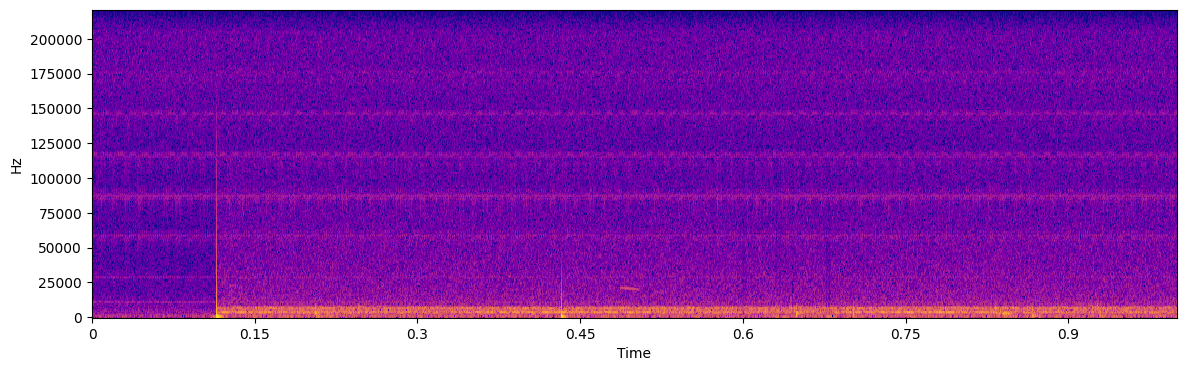

In [35]:
empty_recording = YUCATAN_AUDIO_DIR / yucatan.id[205]
plotting_utils.plot_spectrogram(
    empty_recording, hop_length=128, n_fft=512, figsize=(14, 4)
)

Esta otra grabación contiene un único pulso de murciélago. Aun así, debes revisarla minuciosamente para asegurarte de que no haya otros sonidos de interés.

Reflexionemos brevemente sobre la anotación. Imagina que estás desarrollando un modelo para detectar automáticamente murciélagos en grabaciones acústicas pasivas, aunque los mismos principios se aplican a muchas otras tareas de aprendizaje automático en el ámbito de la investigación.

Es posible que ya dispongas de un conjunto de grabaciones y de un equipo de expertos (quizás tú mismo) capaces de identificar acústicamente las especies de murciélagos de tu región.
¿Cómo organizarías un proyecto de anotación y proporcionarías instrucciones claras para garantizar que las anotaciones sean coherentes y estén alineadas con tus objetivos de aprendizaje automático?

En general, deberías tener en cuenta los siguientes aspectos al diseñar las directrices de anotación para tu equipo:

1. ¿Qué se considera un sonido objetivo?
Define claramente el tipo de sonido o evento que deseas anotar (por ejemplo, llamadas de ecolocalización de murciélagos, llamadas sociales o ruido de fondo).

2. ¿Cómo debe anotarse cada sonido objetivo?
Decide el nivel de detalle: ¿los anotadores marcarán la presencia o ausencia, o delimitarán con precisión cada llamada mediante cuadros? La elección influye tanto en el esfuerzo requerido como en la utilidad de las anotaciones.

3. ¿Qué define una anotación completa?
Especifica los criterios que determinan cuándo una grabación o un segmento se considera totalmente anotado.

4. ¿Cómo deben abordarse los casos ambiguos?
A menudo surgen ambigüedades debido a sonidos inusuales o casos límite. Revisar una muestra diversa de grabaciones puede ayudar a prevenir confusiones. Planifica cómo documentar o resolver los ejemplos ambiguos.

5. ¿Cómo puedes garantizar la coherencia entre los distintos anotadores y sesiones?
Considera estrategias como el uso de ejemplos compartidos, sesiones de calibración o verificaciones del grado de acuerdo entre anotadores.

Al igual que **MegaDetector** para cámaras trampa, existen herramientas que detectan automáticamente sonidos de animales en grabaciones.

Se han desarrollado y entrenado diversos modelos para distintos grupos taxonómicos. Los siguientes son ejemplos muy populares, todos ellos basados ​​en el aprendizaje profundo (*deep learning*):

#### Aves

**BirdNET:** Una red neuronal convolucional de la Universidad de Cornell para clasificar más de 5000 cantos de aves en grabaciones de audio.
> Kahl, S., Wood, C.M., Eibl, M. y Klinck, H., 2021. BirdNET: A deep learning solution for avian
> diversity monitoring. Ecological Informatics, 61, p.101236.
> [https://www.sciencedirect.com/science/article/pii/S1574954121000273](https://www.sciencedirect.com/science/article/pii/S1574954121000273)

[GitHub](https://github.com/kahst/BirdNET-Analyzer)

**Perch:** Concepto similar; modelo entrenado con más de 10 000 especies.
[GitHub](https://github.com/google-research/perch)

#### Murciélagos

**BatDetect2:** Un marco de trabajo en PyTorch para la detección y clasificación simultánea de murciélagos del Reino Unido.
> Aodha, O.M., Martínez Balvanera, S., Damstra, E., Cooke, M., Eichinski, P., Browning, E.,
> Barataud, M., Boughey, K., Coles, R., Giacomini, G. y Swiney G, M.C.M., 2022. Towards a general
> approach for bat echolocation detection and classification. bioRxiv, pp.2022-12. > [https://www.biorxiv.org/content/10.1101/2022.12.14.520490v1.abstract](https://www.biorxiv.org/content/10.1101/2022.12.14.520490v1.abstract)

[GitHub](https://github.com/macaodha/batdetect2)

A continuación, utilizaremos BatDetect2 con nuestros datos. Aunque el modelo se entrenó con vocalizaciones de murciélagos del Reino Unido, podemos evaluar su rendimiento de detección utilizando el conjunto de datos de murciélagos de la península de Yucatán.

💡 Asegúrate de utilizar un entorno de ejecución con GPU para esto. Aun así, el proceso puede tardar un tiempo, ya que tenemos una cantidad considerable de grabaciones de audio que analizar.

💡 BatDetect2 calcula internamente espectrogramas para detectar y clasificar las vocalizaciones de los murciélagos, tal como hicimos manualmente anteriormente ([código fuente](https://github.com/macaodha/batdetect2/blob/2100a3e483116037c57698c72bbe506c604ebd0b/batdetect2/train/audio_dataloader.py#L521)).

**BatDetect2** puede predecir múltiples cuadros delimitadores (*bounding boxes*) para cada grabación. Cada cuadro delimitador cuenta con una **puntuación** (*score*), una especie predicha y un nivel de confianza para dicha especie.

En este caso, descartaremos la especie predicha y el nivel de confianza, y utilizaremos únicamente la puntuación del cuadro delimitador. Dicha **puntuación** representa el grado de confianza del modelo en que el cuadro delimitador contiene una vocalización de ecolocalización de murciélago.

In [36]:
# Listar todos los archivos en el directorio de audio de Yucatán
files = api.list_audio_files(DATA_DIR / "yucatan" / "audio")

# Leer cada archivo de predicciones
batdetect2_predictions = []
for path in tqdm(files):
    # Ejecutar batdetect2 sobre el archivo

    audio = api.load_audio(path)
    spec = api.generate_spectrogram(audio)
    detections, features = api.process_spectrogram(spec)
    output = api.process_file(path)

    # Recopilar la información que necesitamos de cada detección del modelo
    pred_dict = output["pred_dict"]
    for index, detection in enumerate(detections):
            batdetect2_predictions.append(
                {
                    "recording_id": pred_dict["id"],
                    "det_prob": detection["det_prob"],
                    "start_time": detection["start_time"],
                    "end_time": detection["end_time"],
                    "low_freq": detection["low_freq"],
                    "high_freq": detection["high_freq"],
                    "features": features[index],
                }
            )


# Y convertirlos en un único dataframe
batdetect2_predictions = pd.DataFrame(batdetect2_predictions)

# Mostrar las primeras filas de las predicciones realizadas por BatDetect2
batdetect2_predictions.head()

  0%|          | 0/1395 [00:00<?, ?it/s]

,recording_id,det_prob,start_time,end_time,low_freq,high_freq,features
0,rain_tortugas_1_250704_21835_22835.wav,0.048,0.0015,0.0107,24609,34208,"[0.0, 0.0, 0.0, 0.26984474, 0.0, 1.366009, 0.2..."
1,rain_tortugas_1_250704_21835_22835.wav,0.042,0.0015,0.0337,69296,81358,"[4.08913, 0.8522536, 0.0, 0.0, 0.0, 0.8092739,..."
2,rain_tortugas_1_250704_21835_22835.wav,0.051,0.0145,0.0565,68437,82164,"[5.111569, 1.6741554, 0.0, 0.0, 0.0, 1.0615236..."
3,rain_tortugas_1_250704_21835_22835.wav,0.717,0.0175,0.0305,24609,29107,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.2510378, 0.0, 0.0,..."
4,rain_tortugas_1_250704_21835_22835.wav,0.033,0.0205,0.0521,93359,112174,"[1.9075608, 1.4036268, 0.0, 0.3720319, 0.0, 0...."


Imagina el escenario más común en ecoacústica: despliegas grabadoras en el campo durante meses y regresas con cientos de horas de audio, cero etiquetas y la sospecha de que hay mucho más de lo que a simple vista se puede revisar. Etiquetar todo manualmente es una misión imposible.

¿Cómo rompemos este cuello de botella? Aquí es donde entra el aprendizaje no supervisado. En lugar de adivinar etiquetas, dejamos que los datos hablen por sí solos.

Gracias a las detecciones de un modelo como BatDetect2, cada llamada de murciélago se traduce en un vector de 32 números que actúa como su "ADN acústico", una huella digital de sus características de frecuencia y tiempo. Utilizando ese perfil numérico, los algoritmos no supervisados nos permiten agrupar llamadas similares, descubrir morfotipos ocultos o separar el ruido del fondo, todo sin necesidad de etiquetas previas.

In [91]:
# tomar una muestra representativa
df_sample = batdetect2_predictions[batdetect2_predictions['det_prob']>0.5]

# extraer los vectores de características (la columna 'features') como un arreglo 2D de NumPy
X_features = np.array(df_sample['features'].tolist())
print(f"Forma de la matriz de características extraídas: {X_features.shape}")

# estandarizar los datos (media 0, varianza 1)
X_scaled = StandardScaler().fit_transform(X_features)

# reducir la dimensionalidad a 2D usando UMAP para poder visualizar los datos
print("Calculando proyección UMAP...")
umap_2d = UMAP(n_neighbors=50,
                min_dist=0.0,
                metric='euclidean',
                random_state=42).fit_transform(X_scaled)

Forma de la matriz de características extraídas: (6614, 32)
Calculando proyección UMAP...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


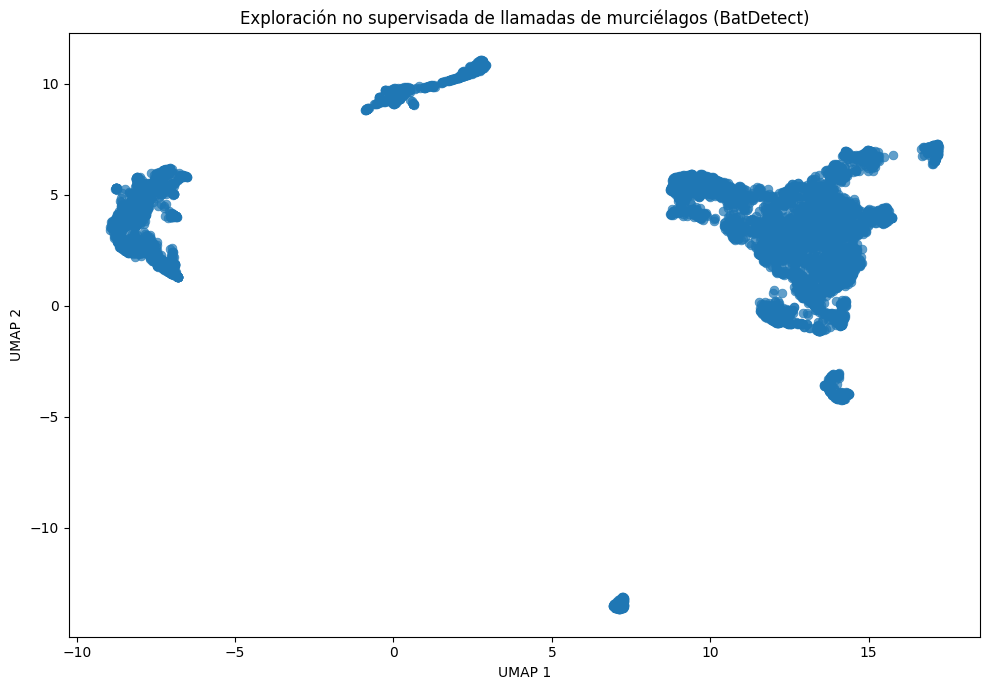

In [92]:
# visualización
plt.figure(figsize=(10, 7))
df_viz = pd.DataFrame(umap_2d, columns=['UMAP1', 'UMAP2'])
df_viz['det_prob'] = df_sample['det_prob']

sns.scatterplot(
    data=df_viz,
    x='UMAP1',
    y='UMAP2',
    alpha=0.7,
    s=40,
    edgecolor=None
)

plt.title("Exploración no supervisada de llamadas de murciélagos", fontsize=12)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
#plt.legend(bbox_to_anchor=(1.05, 1), loc=2, title="Clúster HDBSCAN")
plt.tight_layout()
plt.show()

In [101]:
# @title Exploración interactiva de parámetros HDBSCAN

# Función interactiva
@widgets.interact(
    min_cluster_size=widgets.IntSlider(min=5, max=300, step=5, value=50, description='Min Cluster:'),
    min_samples=widgets.IntSlider(min=1, max=100, step=2, value=30, description='Min Samples:')
)
def interact_hdbscan(min_cluster_size, min_samples):
    # ¡CAMBIO CLAVE!: aplicar HDBSCAN sobre umap_2d en lugar de X_scaled
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
    cluster_labels = clusterer.fit_predict(umap_2d)

    # resumen rápido
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    print(f"Clústeres descubiertos: {n_clusters}")
    print(f"Ruido (-1): {n_noise} ({n_noise/len(cluster_labels):.1%})")

    # preparar datos para graficar
    df_viz = pd.DataFrame(umap_2d, columns=['UMAP1', 'UMAP2'])
    df_viz['cluster'] = [str(c) if c != -1 else 'Ruido (-1)' for c in cluster_labels]

    df_sample['cluster'] = cluster_labels

    # visualización
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=df_viz,
        x='UMAP1',
        y='UMAP2',
        hue='cluster',
        palette='tab10',
        alpha=0.7,
        s=35,
        edgecolor=None
    )
    plt.title(f"HDBSCAN en vivo (min_cluster_size={min_cluster_size}, min_samples={min_samples})", fontsize=12)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, title="Clústeres")
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=50, description='Min Cluster:', max=300, min=5, step=5), IntSlider(value…

### ¿Qué sigue después del Clustering? De los datos a la ecología

El gráfico interactivo que acabamos de construir no es solo una visualización llamativa; en la práctica real de la ecoacústica, representa un ahorro de cientos de horas de esfuerzo humano. A continuación, exploramos cómo llevar este análisis no supervisado al terreno aplicado:

#### 1. Anotación guiada y etiquetado masivo (Bulk Annotation)
Si el algoritmo logró agrupar 2,000 llamadas en un clúster muy denso y bien separado, **ya no es necesario revisar cada audio uno por uno**. Basta con extraer una muestra aleatoria de 20 o 30 espectrogramas de ese grupo. Si todas resultan tener la estructura acústica esperada (por ejemplo, las llamadas de *Myotis keaysi*) o resultan ser ruido constante de fondo (como lluvia), el experto puede etiquetar en bloque esas 2,000 detecciones en un solo paso. Esto transforma un océano de audios inmanejables en un conjunto de entrenamiento limpio en una fracción del tiempo.

#### 2. ¿Cómo evaluamos si el algoritmo hizo un buen trabajo?
A diferencia de la clasificación supervisada, donde evaluamos la "precisión" y "exhaustividad", el mundo no supervisado se evalúa de manera distinta:
* **Evaluación Cualitativa (La prueba del biólogo):** Es lo que hicimos en la celda anterior. Consiste en extraer ejemplos aleatorios de un mismo clúster, observar sus espectrogramas en crudo y preguntarnos: *¿Pertenecen todos a este mismo morfotipo acústico?*
* **Evaluación Cuantitativa:** Consiste en medir qué tan compactos y separados están los grupos matemáticamente (por ejemplo, utilizando el Coeficiente de Silueta), o calcular la "pureza" del clúster al cruzarlo con un pequeño conjunto de validación anotado a mano para verificar si el algoritmo mezcló especies diferentes.

#### 3. El valor ecológico y el cierre del ciclo
La utilidad de este método va más allá de clasificar lo conocido. Es una red de arrastre perfecta para **descubrir vocalizaciones raras** que habrían quedado sepultados y olvidados entre millones de grabaciones comunes. Además, funciona como el filtro definitivo para limpiar falsos positivos generados por detectores automáticos como BatDetect2 (eliminando roces de ramas o cantos de insectos de alta frecuencia agrupados como "Ruido").

**El siguiente paso natural:** Tomar estos clústeres (ya limpios y curados por el investigador de manera eficiente) y utilizarlos como datos de entrenamiento para crear un modelo de clasificación supervisado y personalizado. Así cerramos el ciclo del aprendizaje automático con herramientas profundamente adaptadas a la fauna local de nuestra zona de estudio.


--- Espectrograma 1: Clúster 4 | Archivo: rain_azul_1_040803_7960_8960.wav ---


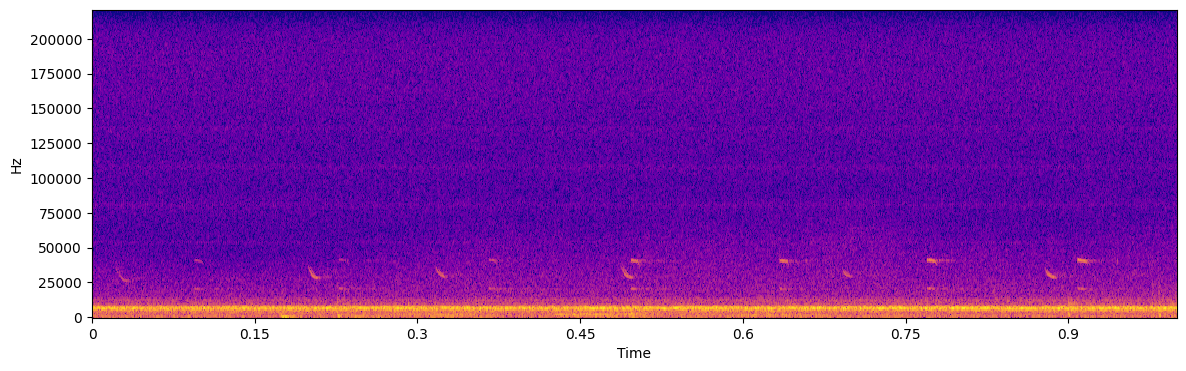


--- Espectrograma 2: Clúster 4 | Archivo: rain_azul_1_040803_49775_50775.wav ---


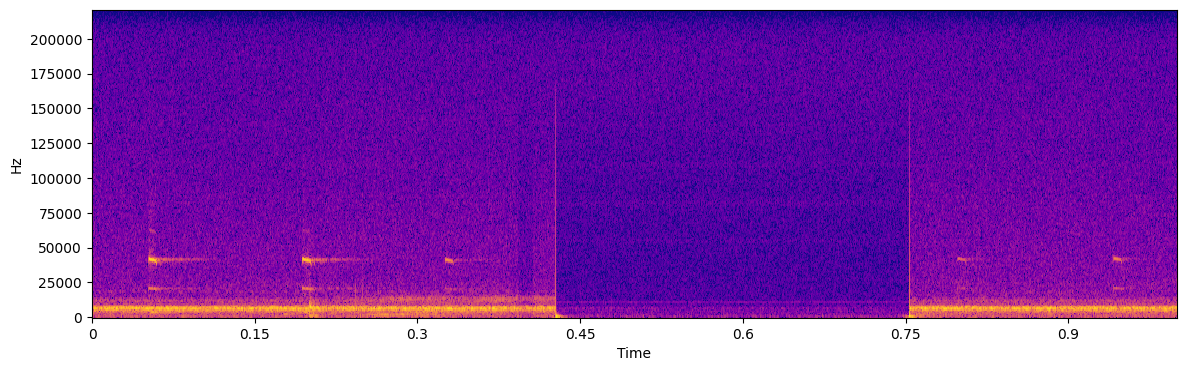


--- Espectrograma 3: Clúster 4 | Archivo: dry_benita_3_130205_5045_6045.wav ---


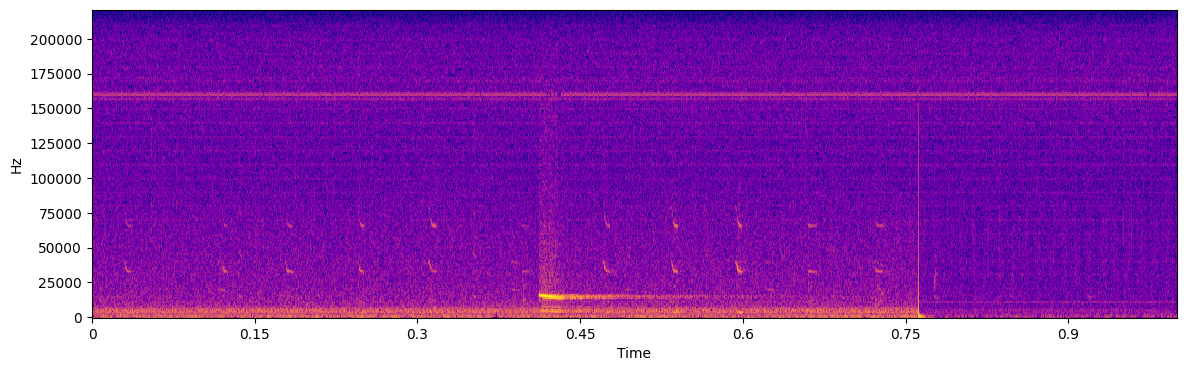

In [99]:
# @title Auditando un clúster

# Elige un clúster válido (fíjate en los números de la gráfica anterior, por ejemplo 0, 1 o 2)
# Si pones -1, auditarás lo que el algoritmo consideró "Ruido"
cluster_id = 4

# Filtramos nuestra muestra y tomamos 3 ejemplos aleatorios de ese clúster
ejemplos_cluster = df_sample[df_sample['cluster'] == cluster_id]

if len(ejemplos_cluster) < 3:
    print(f"El clúster {cluster_id} no tiene suficientes ejemplos. Elige otro.")
else:
    ejemplos_aleatorios = ejemplos_cluster.sample(n=3, random_state=42)

    for i, (_, row) in enumerate(ejemplos_aleatorios.iterrows()):
        archivo_audio = YUCATAN_AUDIO_DIR / row['recording_id']

        print(f"\n--- Espectrograma {i+1}: Clúster {cluster_id} | Archivo: {row['recording_id']} ---")

        # 2. Visualización usando la función de las utilidades del taller
        plotting_utils.plot_spectrogram(
            archivo_audio, hop_length=128, n_fft=512, figsize=(14, 4)
        )
        plt.show() # Asegura que se renderice cada figura por separado

Supongamos ahora que tenemos datos etiquetados. ¿Son estas buenas predicciones? Para averiguarlo, debemos compararlos con la verdad fundamental.

Primero carguemos algunas anotaciones de verdad sobre el terreno realizadas anteriormente.

In [56]:
# Cargar el archivo de anotaciones
yucatan_annotations = pd.read_csv(DATA_DIR / "yucatan" / "yucatan_annotations.csv")

# Mostrar las primeras filas
yucatan_annotations.head()

,recording_id,end_time,start_time,low_freq,high_freq,event,class
0,dry_azul_1_140305_54686_55686.wav,0.581549,0.573141,37467.773438,43066.406250,Echolocation,Pteropteryx macrotis
1,dry_azul_1_140305_54686_55686.wav,0.995651,0.986776,24978.515625,28854.492188,Echolocation,Bat
2,dry_azul_1_140305_54686_55686.wav,0.930721,0.922780,41774.414063,45219.726563,Echolocation,Pteropteryx macrotis
3,dry_azul_1_140305_54686_55686.wav,0.849209,0.837764,36606.445313,43066.406250,Echolocation,Pteropteryx macrotis
4,dry_azul_1_140305_54686_55686.wav,0.576410,0.566134,41343.750000,45219.726563,Echolocation,Pteropteryx macrotis


In [59]:
len(yucatan_annotations['class'].unique())

24

Ahora podemos comparar las detecciones con la verdad de referencia (*ground truth*). Podemos utilizar la métrica de intersección sobre unión (IoU, por sus siglas en inglés) para medir el solapamiento entre las detecciones y la verdad de referencia.

<img alt="intersection over union"
src="https://upload.wikimedia.org/wikipedia/commons/c/c7/Intersection_over_Union_-_visual_equation.png"
width="400"></img>

Intuitivamente, la relación entre el solapamiento (intersección) y la unión nos indica el grado de similitud geométrica entre dos cajas delimitadoras. Un valor de IoU de 1 significa que ambas cajas son congruentes (se solapan perfectamente), mientras que un IoU de 0 indica que las dos cajas ni siquiera se tocan.

Por lo general, no cabe esperar que un modelo de aprendizaje automático genere siempre cajas delimitadoras idénticas a las de la verdad de referencia. Por ello, es necesario establecer un valor mínimo de IoU a partir del cual consideraremos que una predicción es «correcta». A continuación, utilizaremos un *umbral de IoU* de 0,5.

In [ ]:
# Select the predictions and annotations from the crowded recording
file_detections = batdetect2_predictions[
    batdetect2_predictions.recording_id == crowded_recording.name
]
file_annotations = yucatan_annotations[
    yucatan_annotations.recording_id == crowded_recording.name
]

# Match the bounding boxes by computing the IoU. Discard all matches with IoU less than 0.5
pred_boxes = evaluation_utils.bboxes_from_annotations(file_detections)
true_boxes = evaluation_utils.bboxes_from_annotations(file_annotations)
matches = evaluation_utils.match_bboxes(true_boxes, pred_boxes, iou_threshold=0.5)

Ahora podemos distinguir tres casos diferentes (recordando lo visto en el cuaderno anterior):
* **Verdaderos positivos (TP)**: _detecciones_ con IoU >= umbral
* **Falsos positivos (FP)**: _detecciones_ con IoU < umbral
* **Falsos negativos (FN)**: _anotaciones_ sin una detección correspondiente

In [ ]:
# total number of annotated sound events
positives = len(file_annotations)

num_predictions = len(file_detections)

# number of matched prediction boxes
true_positives = len(matches)

# number of predicted boxes that were not matched
false_positives = num_predictions - len(matches)

# number of annotated sound events that were not matched
false_negatives = positives - len(matches)

Con esta información, podemos calcular la precisión y la exhaustividad de las detecciones:
$$
\text{Precisión} = \frac{\text{TP}}{\text{TP + FP}}
$$

$$
\text{Exhaustividad} = \frac{\text{TP}}{\text{TP + FN}}
$$

In [ ]:
# Percentage of predictions that are correct
precision = true_positives / num_predictions

# Percentage of sound events that were detected
recall = true_positives / positives

print(
    f"BatDetect2 precision={precision:.1%} recall={recall:.1%} on file {crowded_recording.name}"
)

Ahora podemos visualizar conjuntamente las predicciones y las anotaciones de referencia en los espectrogramas:

In [ ]:
score_threshold = 0.2
iou_threshold = 0.1

plotting_utils.plot_spectrogram_with_predictions_and_annotations(
    crowded_recording,
    batdetect2_predictions[batdetect2_predictions.det_prob > score_threshold],
    yucatan_annotations,
    iou_threshold=iou_threshold,
)

En la visualización anterior, los cuadros delimitadores se dibujan con diferentes estilos:
- rojo = evento sonoro predicho erróneamente (falso positivo)
- verde = predicción correcta (verdadero positivo)
- blanco = evento sonoro no detectado (falso negativo)

Además de un umbral de IoU, observará que también es necesario establecer un *umbral de confianza*, ya que,
como se ha explicado anteriormente, BatDetect2 proporciona una puntuación de confianza.

En el ejemplo anterior, hemos fijado este valor en 0,3 de forma más bien arbitraria. Puede imaginar qué sucede si aumentamos o
disminuimos este umbral. Observe lo que ocurre con distintos archivos al ajustar los umbrales de IoU y de confianza
en el widget que aparece a continuación.

In [ ]:
# Selecciona un archivo y un umbral de IoU.
example_files = [
    YUCATAN_AUDIO_DIR / row["id"] for _, row in yucatan.sample(n=20).iterrows()
]


@ipywidgets.interact(
    path=[(path.name, path) for path in example_files],
    iou_threshold=(0, 1, 0.025),
    score_threshold=(0, 1, 0.025),
)
def plot_batdetect2_results_file_results(
    path=crowded_recording,
    iou_threshold=0.5,
    score_threshold=0.3,
):
    confident_detections = batdetect2_predictions[
        batdetect2_predictions.det_prob > score_threshold
    ]

    precision, recall = evaluation_utils.compute_file_precision_recall(
        path,
        confident_detections,
        yucatan_annotations,
        iou_threshold=iou_threshold,
    )

    print(
        f"Batdetect2 precision={precision:.1%} recall={recall:.1%} on file {path.name}"
    )

    plotting_utils.plot_spectrogram_with_predictions_and_annotations(
        path,
        confident_detections,
        yucatan_annotations,
        iou_threshold=iou_threshold,
        linewidth=1,
    )

🖌️ Con la ayuda de los bloques de código anteriores, implementa el cálculo de las siguientes propiedades:

* La precisión y la exhaustividad (*recall*) medias en todos los archivos.
* El porcentaje de archivos en los que no se detectó ninguna llamada de murciélago.

In [ ]:
precisions, recalls = [], []  # lista de puntuaciones de precisión y recall por archivo
files_missed = 0  # contador del número de archivos en los que se perdieron todas las llamadas


for recording_id in batdetect2_predictions.recording_id.unique():
    file_detections = batdetect2_predictions[
        batdetect2_predictions.recording_id == recording_id
    ]
    file_annotations = yucatan_annotations[
        yucatan_annotations.recording_id == recording_id
    ]

    # Empareja las cajas delimitadoras calculando el IoU. Descarta todos los emparejamientos con IoU menor a 0.5
    pred_boxes = evaluation_utils.bboxes_from_annotations(file_detections)
    true_boxes = evaluation_utils.bboxes_from_annotations(file_annotations)
    matches = evaluation_utils.match_bboxes(true_boxes, pred_boxes, iou_threshold=0.5)

    # número total de eventos de sonido anotados
    positives = len(file_annotations)

    num_predictions = len(file_detections)

    # número de cajas de predicción que coincidieron
    true_positives = len(matches)

    # número de cajas de predicción que no coincidieron
    false_positives = num_predictions - len(matches)

    # número de eventos de sonido anotados que no coincidieron
    false_negatives = positives - len(matches)

    # Porcentaje de predicciones que son correctas
    if num_predictions == 0:
        precision = 0
    else:
        precision = true_positives / num_predictions

    # Porcentaje de eventos de sonido que fueron detectados
    if positives == 0:
        recall = 0
    else:
        recall = true_positives / positives

    precisions.append(precision)
    recalls.append(recall)

    # incrementa el contador si se perdieron todas las llamadas de murciélago
    if true_positives == 0 and positives > 0:
        files_missed += 1

print(
    f"Precisión media = {np.mean(precisions):.2%}, Recall medio = {np.mean(recalls):.2%}."
)
print(
    f"Porcentaje de archivos en los que se perdieron todas las llamadas de murciélago = {files_missed/len(precisions):.2%}."
)

🖌️ Vuelve a ejecutar la evaluación completa, pero cambia el parámetro `iou_threshold`. ¿Qué observas?

* Aumentar el **umbral de IoU** dificulta encontrar coincidencias (`true_positives`). La exhaustividad (*recall*) disminuirá necesariamente, ya que se podrán detectar menos llamadas de murciélago. La precisión también se reducirá, dado que habrá menos detecciones correctas.

* Por el contrario, un **umbral de IoU** más bajo aumenta el número de coincidencias (`true_positives`), lo que incrementa tanto la exhaustividad como la precisión.

* La selección de un **umbral de IoU** no consiste en optimizar el rendimiento, sino en elegir un criterio de correspondencia. Un **umbral de IoU** bajo puede aumentar la exhaustividad y la precisión, pero a costa de la precisión en la delimitación de la caja envolvente (*bounding box*) de cada detección.

A continuación, podemos visualizar las predicciones de BatDetect2 frente a las etiquetas de referencia para una selección de archivos de audio.

In [ ]:
# Selecciona un archivo y un umbral de IoU.
example_files = [
    YUCATAN_AUDIO_DIR / row["id"] for _, row in yucatan.sample(n=20).iterrows()
]


@ipywidgets.interact(
    path=example_files,
    iou_threshold=(0, 1, 0.1),
    score_threshold=(0, 1, 0.1),
)
def plot_batdetect2_results_file_results(
    path=crowded_recording,
    iou_threshold=0.5,
    score_threshold=0.3,
):
    confident_detections = batdetect2_predictions[
        batdetect2_predictions.det_prob > score_threshold
    ]

    precision, recall = evaluation_utils.compute_file_precision_recall(
        path,
        confident_detections,
        yucatan_annotations,
        iou_threshold=iou_threshold,
    )

    print(
        f"Batdetect2 precision={precision:.1%} recall={recall:.1%} on file {crowded_recording}"
    )

    plotting_utils.plot_spectrogram_with_predictions_and_annotations(
        path,
        confident_detections,
        yucatan_annotations,
        iou_threshold=iou_threshold,
        linewidth=2,
    )

**🛑 Debate en grupo**

En esta sección, exploramos cómo evaluar el rendimiento de BatDetect2 en la identificación de pulsos de ecolocalización utilizando métricas como la precisión y la exhaustividad (*recall*).
Estas métricas de evaluación resumen el rendimiento del modelo a partir de numerosos ejemplos, y cada una de ellas captura únicamente un aspecto específico de dicho comportamiento.
Por ejemplo, no evaluamos en qué medida las cajas delimitadoras predichas coinciden con las anotaciones realizadas por expertos.

Tómese un momento para reflexionar sobre las siguientes preguntas antes de que las debatamos en grupo:

1. Para las tareas de aprendizaje automático (*machine learning*) de su investigación, ¿qué métricas de evaluación están disponibles y cuáles son las que se utilizan con mayor frecuencia?
2. ¿Se alinean estas métricas con los objetivos generales de su investigación? A menudo se adoptan métricas por ser el estándar en la investigación de aprendizaje automático, pero es posible que no reflejen plenamente —ni ofrezcan una visión integral de— sus objetivos ecológicos o científicos.
3. ¿Quiénes son los usuarios potenciales de los resultados de su investigación? Si ya los ha identificado, ¿qué información necesitarían para tomar decisiones fundamentadas sobre cómo y cuándo utilizar sus resultados?

## 6. Puede un modelo de aves clasificar murciélagos? <a id="murcis"></a>

En la sección anterior, vimos cómo detectar sonidos en una grabación. Sin embargo, todavía es necesario identificar la especie que produjo el sonido.

Por lo general, la clasificación es más compleja que la detección, ya que los sonidos emitidos por distintas especies pueden ser muy similares (**solapamiento interespecífico**). Además, una misma especie puede presentar vocalizaciones variables —como ocurre con los seres humanos o con aves imitadoras como el estornino— (**variación intraespecífica**).

Los datos bioacústicos plantean desafíos similares a los de las cámaras trampa, dado que las grabaciones pueden presentar las siguientes características:
* **Oclusiones** (sonidos simultáneos)
* **Condiciones ambientales variables** (lluvia, viento, truenos)
* **Fragmentación** (solo se captura una parte del sonido)
* **Ruido** (saturación y fallos en el sensor)
* **Volumen bajo o muy alto** (en función del tamaño del animal, la distancia y el entorno)

En el resto de este cuaderno, nos centraremos en **10** especies de murciélagos presentes en el conjunto de datos de Yucatán.

In [ ]:
SPECIES = [
    "Mormoops megalophylla",
    "Myotis keaysi",
    "Saccopteryx bilineata",
    "Pteronotus davyi",
    "Pteronotus parnellii",
    "Lasiurus ega",
    "Pteropteryx macrotis",
    "Eumops underwoodi",
    "Rhogeessa aeneus",
    "Eptesicus furinalis",
]

classification_df = yucatan_annotations[yucatan_annotations["class"].isin(SPECIES)]

### 6.1 Características de las llamadas de los murciélagos

Las investigaciones previas sobre la identificación de llamadas de murciélagos se basaban en características definidas manualmente.
La medición de las características de las llamadas solía ser un proceso manual.

<img src="https://www.elekon.ch/batexplorer2/doc/_images/CallParams.png" alt="parámetros de llamada" width="400"/>

> Imagen tomada de la [guía de usuario de BatExplorer 2.1](https://www.elekon.ch/batexplorer2/doc/batcall_params.html).

**Frecuencia pico [kHz]:**

>    La frecuencia a la que la llamada tiene mayor intensidad (pico en la visualización del espectro), también conocida como frecuencia de energía máxima (FME) o frecuencia principal.
>    Es el parámetro más importante para la clasificación de murciélagos, ya que puede medirse fácilmente y suele ser característico de una especie o grupo de especies determinado.
>    La desviación estándar de la frecuencia pico permite detectar especies que alternan diferentes tipos de llamadas.

**Frecuencia máxima [kHz]**

>    La frecuencia máxima de la llamada. A menudo coincide con la frecuencia de inicio; en el caso de los rinolófidos (Rhinolophidae), suele coincidir con la frecuencia pico.

**Frecuencia mínima [kHz]**

>    La frecuencia mínima de la llamada. A menudo coincide con la frecuencia final; sin embargo, en las llamadas con forma de "palo de hockey" (p. ej., *Pipistrellus*), puede ser inferior a la frecuencia final.

**Ancho de banda Pico-Mínimo (BW Peak2Min) [kHz]**

>    Ancho de banda Pico-Mínimo = Frecuencia pico - Frecuencia mínima.
>    Se utiliza a menudo para distinguir entre las llamadas de *Myotis* y *Pipistrellus*; las de *Myotis* suelen presentar un ancho de banda mayor.

**Duración de la llamada [ms]**

>    Intervalo de tiempo desde el inicio hasta el final de la llamada, expresado en ms. Se mide con mayor precisión en el oscilograma (desde el ascenso hasta el descenso de la onda).
>    Las llamadas de exploración de los murciélagos europeos suelen durar entre 1 y aproximadamente 30 ms (en los murciélagos de herradura pueden llegar hasta los 80 ms).

**Intervalo entre llamadas [ms]**

>    Intervalo de tiempo entre dos llamadas consecutivas, expresado en ms. Se puede medir con mayor precisión en el oscilograma (desde el inicio de la llamada A hasta el inicio de la llamada B).
>    A menudo, este parámetro no es muy significativo, ya que la mayoría de las especies de murciélagos presentan ritmos irregulares. No obstante, puede servir como indicador de comportamiento.
>    Los intervalos entre llamadas de búsqueda de los murciélagos europeos suelen oscilar entre 30 y 300 ms, llegando a veces a ser incluso mayores.

### 6.2 Un paso más allá: clasificación de sonidos mediante aprendizaje por transferencia

**El aprendizaje por transferencia en pocas palabras:** en lugar de entrenar un modelo de aprendizaje profundo desde cero —lo cual requiere enormes cantidades de datos etiquetados y capacidad de cómputo—, tomamos prestado un modelo ya entrenado por otra persona y reutilizamos lo que aprendió para nuestro propio problema, que es de menor escala. Esto es lo que permite que modelos potentes sean utilizables por equipos pequeños con conjuntos de datos reducidos.


En la Sección 3, utilizamos BatDetect2 para localizar vocalizaciones de murciélagos en espectrogramas.
Sin embargo, no podíamos utilizar las especies que el modelo predecía, ya que correspondían a ejemplares del Reino Unido
y no se encuentran en Yucatán (y BatDetect2 tampoco reconoce las especies de esta última región).

Si queremos realizar ambas tareas —es decir, detectar *y* clasificar las vocalizaciones de los murciélagos—, tenemos dos opciones:

1. Reentrenar BatDetect2 con el conjunto de datos de Yucatán, ya sea desde cero o adaptando
el modelo entrenado con datos del Reino Unido. No obstante, este enfoque suele requerir un gran número de
muestras etiquetadas y un ajuste fino (*fine-tuning*) minucioso, lo cual no siempre resulta viable.

2. Entrenar un clasificador más sencillo que utilice un conjunto de características extraídas de cada
vocalización para predecir la especie.

A continuación, exploraremos la segunda opción. Esta estrategia suele preferirse en bioacústica,
campo en el que entrenar grandes modelos de aprendizaje profundo puede resultar técnicamente complejo
y exigir una gran cantidad de datos.

Tradicionalmente, estos clasificadores se basan en características definidas manualmente —mediciones
identificadas por expertos en murciélagos para ayudar a distinguir entre especies, como las mencionadas anteriormente—.
Sin embargo, obtener estas características puede llevar mucho tiempo y, en ocasiones, requiere anotación manual.
Además, dichas características se han estudiado principalmente en un conjunto reducido de especies,
en su mayoría de regiones templadas; aun así, no siempre permiten diferenciar con fiabilidad
entre especies acústicamente similares.

Dado que nuestro conocimiento sobre la acústica de los murciélagos es aún incompleto, es probable
que existan otras características informativas que los expertos aún no han identificado.
Un enfoque basado en datos, en el que aprendemos características útiles directamente a partir
de la información disponible, ofrece una alternativa poderosa. Esto es exactamente lo que hacen los modelos modernos de aprendizaje profundo: durante el entrenamiento, aprenden automáticamente a calcular representaciones internas —también llamadas *embeddings*— que captan características significativas de los sonidos de entrada.

Podemos aprovechar esto utilizando un modelo preentrenado para extraer dichas características de nuestras grabaciones de murciélagos. Aunque el modelo no se haya entrenado específicamente con datos de murciélagos, una red entrenada con un conjunto de datos de audio amplio y diverso debería haber aprendido a captar patrones acústicos universales y generales. Al utilizar estos *embeddings* como características de entrada, efectivamente **transferimos** el conocimiento adquirido por el modelo a una tarea nueva pero relacionada: en este caso, la clasificación de las vocalizaciones de los murciélagos.

Si el modelo de aprendizaje profundo logra resumir el contenido del espectrograma «lo suficientemente bien», podremos entrenar un clasificador ligero —como un bosque aleatorio (*Random Forest*)— para predecir la especie objetivo con mayor facilidad.

Para ello, utilizaremos un extractor de características acústicas de propósito general llamado
[Yamnet](https://github.com/tensorflow/models/tree/master/research/audioset/yamnet).

Yamnet fue entrenado con [AudioSet](http://research.google.com/audioset/), un conjunto de datos masivo de grabaciones de YouTube
que contiene más de 5800 horas de audio.

Se entrenó para clasificar fragmentos de sonido en 527 categorías distintas. Por tanto, las características que aprendió a
extraer resultan útiles para distinguir e identificar una gran variedad de sonidos.

<img src="http://research.google.com/audioset/resources/histogram.svg" alt="conjunto de datos audioset"
width="400"/>

AudioSet no contiene grabaciones ultrasónicas y, por consiguiente, carece de sonidos de murciélagos. No obstante,
esperamos que las características aprendidas sean lo suficientemente generales como para ayudar a identificar las vocalizaciones de los murciélagos.

En primer lugar, debemos descargar el modelo. El modelo está disponible en [TensorFlow Hub](https://tfhub.dev/), un repositorio de modelos preentrenados.

In [ ]:
# Carga el modelo usando tensorflow_hub
yamnet = hub.load("https://tfhub.dev/google/yamnet/1")

A continuación, cargaremos todos los fragmentos de audio del conjunto de datos y extraeremos las características utilizando el modelo.

YamNet se entrenó originalmente con clips de audio de 0,96 segundos muestreados a 16 kHz, lo que corresponde a $0,96 \times 16000 = 15360$ muestras de audio individuales.
Sin embargo, todas nuestras grabaciones tienen una frecuencia de muestreo de 44,1 kHz. Por ello, alimentaremos el modelo con segmentos de audio de 34 ms cada vez, lo que equivale a esas mismas 15 360 muestras.

Centraremos cada clip de audio en las vocalizaciones de los murciélagos.

In [ ]:
# Aquí cargaremos la información de dónde comienza y termina cada llamada de murciélago
audio_clips = pd.read_csv(DATA_DIR / "yucatan" / "yucatan_species_clips.csv")

In [51]:
def load_annotation_audio(row, num_samples: int, time_buffer: float = 0.01):
    # Agrega un poco de relleno de audio extra a la izquierda y derecha de la llamada anotada
    start_time = row.start_time - time_buffer
    end_time = row.end_time + time_buffer

    # Carga solo el audio entre el tiempo de inicio y fin declarado
    audio, _ = audio_utils.load_audio(
        path=str(YUCATAN_AUDIO_DIR / row.recording_id),
        start_time=start_time,
        end_time=end_time,
    )

    if audio.ndim > 1:
        # Selecciona solo el primer canal de audio
        audio = audio[:, 0]

    if len(audio) > num_samples:
        # Si el audio es más largo que el número de muestras necesarias, córtalo al tamaño
        return audio[:num_samples]

    if len(audio) < num_samples:
        # Si el audio es demasiado corto, entonces necesitamos rellenarlo con silencio al final
        return np.pad(
            audio,
            [
                [0, num_samples - len(audio)],
            ],
            mode="constant",
            constant_values=0,
        )

    return audio

Calculemos los vectores de características con YamNet para cada una de nuestras llamadas de murciélago.

In [ ]:
yamnet_features = []
for _, row in tqdm(audio_clips.iterrows(), total=len(audio_clips)):
    # Extrae audio de alrededor de la llamada
    wav = load_annotation_audio(row, num_samples=int(0.96 * 16_000))

    # Procesa con yamnet
    scores, feats, spectrogram = yamnet(wav)

    # Almacena las características extraídas
    yamnet_features.append(feats.numpy().squeeze())

yamnet_features = np.array(yamnet_features)

Ten en cuenta que YamNet devuelve un conjunto de 1024 características para cada clip de audio:

In [ ]:
print(yamnet_features.shape)

Aún no sabemos si esas características son realmente útiles para distinguir nuestras especies de murciélagos de Yucatán.
Por ello, primero podemos visualizar las características utilizando una técnica de reducción de dimensionalidad: [UMAP](https://umap-learn.readthedocs.io/en/latest/).

In [ ]:
umap_yamnet = UMAP().fit_transform(StandardScaler().fit_transform(yamnet_features))

In [ ]:
X, Y = umap_yamnet.T
plt.figure(figsize=(10, 10))
sns.scatterplot(x=X, y=Y, hue=audio_clips["class"])

Parece difícil distinguir las especies de murciélagos basándose en los conjuntos de características y en este gráfico UMAP. No obstante, intentemos utilizar dichas características como entrada para un clasificador y así comprobar realmente qué tan bien funciona.

Aquí construirás un clasificador de bosque aleatorio (Random Forest) utilizando las características extraídas por YamNet.

🖌️ Divide los datos en conjuntos de entrenamiento y prueba. Utiliza el 30 % de los datos para las pruebas.

In [ ]:
# separa el conjunto de datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train_yamnet, X_test_yamnet, y_train_yamnet, y_test_yamnet = train_test_split(
    yamnet_features,
    audio_clips["class"],
    test_size=0.3,
    stratify=audio_clips["class"],  # observa que estamos usando el argumento "estratificado"
)

🖌️ Entrena un clasificador de bosque aleatorio utilizando los datos de entrenamiento.

In [ ]:
# build a random forest model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

# fit to training data
rf.fit(X_train_yamnet, y_train_yamnet)

En esta ocasión, utilizaremos validación cruzada en lugar de un conjunto de validación específico. Scikit-learn pone a nuestra disposición una función muy útil:
[cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html).

🖌️ Implementa la validación cruzada completando la celda de código que aparece a continuación. Luego, ajusta los hiperparámetros del modelo Random Forest basándote en este resultado hasta que estés satisfecho y listo para pasar al conjunto de prueba.

In [ ]:
from sklearn.model_selection import cross_val_score

# crea un nuevo objeto Random Forest
rf = RandomForestClassifier(n_estimators=500)

# calcula las puntuaciones de rendimiento de la validación cruzada (CV)
scores = cross_val_score(rf, X_train_yamnet, y_train_yamnet, cv=5)

# informa las estadísticas de las puntuaciones de CV
print(f"CV score mean: {scores.mean():.2%}, std: {scores.std():.2%}.")

🖌️ Una vez que estés satisfecho con el rendimiento, evalúalo utilizando la función `classification_report`.

In [ ]:
# todavía necesitamos ajustar el modelo final
rf.fit(X_train_yamnet, y_train_yamnet)

# realiza predicciones en el conjunto de prueba
y_pred_yamnet = rf.predict(X_test_yamnet)

# evalúa utilizando el informe de clasificación
print(classification_report(y_true=y_test_yamnet, y_pred=y_pred_yamnet))

🖌️ Representa la matriz de confusión. Consejo: consulta la [documentación de scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).

In [ ]:
# calcula la matriz de confusión y normaliza cada fila para obtener porcentajes
cm = confusion_matrix(y_true=y_test_yamnet, y_pred=y_pred_yamnet, normalize="true")

_, ax = plt.subplots(figsize=(8, 8))

# dibuja la matriz de confusión utilizando ConfusionMatrixDisplay
ConfusionMatrixDisplay(cm, display_labels=rf.classes_).plot(
    xticks_rotation="vertical", values_format=".0%", ax=ax
);

🖌️ ¿Cuáles son las especies con peor rendimiento? ¿Puedes ver por qué? Es posible que necesites volver atrás y revisar más ejemplos de vocalizaciones de murciélagos.

💡 **Nota**: Es probable que los resultados varíen en cada ejecución, ya que la división del conjunto de datos y el entrenamiento del bosque aleatorio (*random forest*) son aleatorios.

*Mormoops megalophylla* y *Eumops underwoodi* fueron las especies con peor desempeño.

Esto podría explicarse por:
*   Un número reducido de ejemplos (véase el campo "support" en la tabla del informe de precisión). Cabe destacar que esto resulta especialmente problemático dado que YamNet genera un vector de características de 1024 dimensiones; con una cantidad insuficiente de ejemplos, nos enfrentamos al problema de la **maldición de la dimensionalidad**.
*   Relacionado con lo anterior está el desequilibrio de clases o, en términos generales, una distribución de clases de "cola larga" (*long-tailed*). Aunque esto afecta menos a los bosques aleatorios (*Random Forests*) que, por ejemplo, a los modelos de aprendizaje profundo (*deep learning*), aun así puede causar problemas graves.
*   Escasa agrupación e insuficiente separación de las características de YamNet (véase el gráfico de dispersión UMAP).
*   Una firma acústica compleja en general (véanse las visualizaciones del espectrograma).

Desde una perspectiva ecológica:

*   Es posible que los ejemplos de entrenamiento no abarquen toda la gama de variaciones en las llamadas. Las llamadas de prueba podrían incluir tipos de llamada no observados durante el entrenamiento. Esto podría solucionarse recopilando más datos o generando datos sintéticos.
*   También parece haber un solapamiento considerable entre las llamadas de ecolocalización de diferentes especies. Esto podría deberse a errores en el etiquetado. Los errores en el proceso de anotación son frecuentes y cabe esperarlos. Se podría solucionar mediante un proceso de revisión en el que se verifiquen o corrijan las anotaciones sospechosas. Una anotación puede marcarse como sospechosa si sus características se alejan mucho de la distribución habitual (detección de valores atípicos) o si el modelo se equivoca con gran confianza respecto a su clase (minería de ejemplos difíciles).
*   Los murciélagos utilizan las llamadas de ecolocalización para desplazarse y detectar presas. Si el espacio de vuelo habitual y/o las presas son similares para dos especies, estas tenderán a utilizar la ecolocalización de manera parecida. En estos casos, emplear un esquema de clasificación diferente para los murciélagos —por ejemplo, uno basado en rasgos ecológicos— podría resultar más adecuado para la tarea de identificación acústica.
*   La producción de sonido también está condicionada por la morfología. Las especies estrechamente emparentadas tienden a tener capacidades de producción de sonido similares y, por tanto, llamadas de ecolocalización parecidas. Sin embargo, esto no siempre ocurre, ya que la llamada de ecolocalización está fuertemente condicionada por la ecología (como se mencionó en el punto anterior). Una posible solución alternativa consiste en clasificar a un nivel taxonómico superior, como el género o la familia.
*   Las características seleccionadas de las llamadas no permiten distinguir entre especies. Es posible que existan indicios sutiles en el audio que faciliten la identificación pero que no se hayan medido. Extrajimos las características mediante YAMNet, modelo que podría no representar con exactitud la información contenida en las llamadas de ecolocalización. Dado que YAMNet no se entrenó con datos ultrasónicos, es posible que no capte características fundamentales de estas señales de alta frecuencia.

### 6.3 Características especializadas con Perch

La solución anterior no funcionó realmente bien. Como se ha visto en el gráfico UMAP, las características de YamNet
no capturan suficientemente los patrones de los datos como para permitir separar las vocalizaciones según la especie de murciélago.

Sin embargo, anteriormente también mencionamos otro modelo entrenado específicamente para datos acústicos:
[Perch](https://github.com/google-research/perch/tree/main). ¿Qué sucede si utilizamos sus características
en lugar de las de YamNet?

En primer lugar, vamos a calcularlas. Perch también está
[disponible](https://www.kaggle.com/models/google/bird-vocalization-classifier/TensorFlow2/bird-vocalization-classifier/8)
en TensorFlow Hub:

In [ ]:
# load model
model_perch = hub.load(
    "https://www.kaggle.com/models/google/bird-vocalization-classifier/TensorFlow2/bird-vocalization-classifier/8"
)

Sin embargo, Perch difiere de Yamnet en la forma en que genera características (y predicciones), ya que procesa 5 segundos de audio a 32 kHz, lo que equivale a $5 \times 32000 = 160000$ muestras de audio.

In [ ]:
perch_features = []
for _, row in tqdm(audio_clips.iterrows(), total=len(audio_clips)):
    # load audio data into memory
    wav = load_annotation_audio(row, num_samples=int(5 * 32_000))

    # predict using Perch
    model_outputs = model_perch.infer_tf(wav[None, :])

    # extract and append features (also known as "embeddings")
    perch_features.append(model_outputs["embedding"])

# combine features into single NumPy array
perch_features = np.array(perch_features).squeeze()

Imprimamos la forma de las características de Perch:

In [ ]:
print(perch_features.shape)

Ligeramente más grande que YamNet (1280 frente a 1024), pero ¿son realmente mejores?

🖌️ Repite los pasos anteriores, incluyendo el cálculo del gráfico UMAP y el entrenamiento y evaluación mediante Random Forest.

In [ ]:
# create UMAP plot
umap_perch = UMAP().fit_transform(StandardScaler().fit_transform(perch_features))
X, Y = umap_perch.T
plt.figure(figsize=(10, 10))
sns.scatterplot(x=X, y=Y, hue=audio_clips["class"])

In [ ]:
# split into train/test sets
X_train_perch, X_test_perch, y_train_perch, y_test_perch = train_test_split(
    perch_features,
    audio_clips["class"],
    test_size=0.3,
    stratify=audio_clips["class"],  # observa que estamos usando el argumento "estratificado"
)


# crea un nuevo objeto Random Forest
rf = RandomForestClassifier(n_estimators=500)

# calcula las puntuaciones de rendimiento de la validación cruzada (CV)
scores = cross_val_score(rf, X_train_perch, y_train_perch, cv=5)

# informa las estadísticas de las puntuaciones de CV
print(f"CV score mean: {scores.mean():.2%}, std: {scores.std():.2%}.")

# entrena el modelo final
rf.fit(X_train_perch, y_train_perch)

# realiza predicciones en el conjunto de prueba
y_pred_perch = rf.predict(X_test_perch)

# evalúa utilizando el informe de clasificación
print(classification_report(y_true=y_test_perch, y_pred=y_pred_perch))

# calcula la matriz de confusión y normaliza cada fila para obtener porcentajes
cm = confusion_matrix(y_true=y_test_perch, y_pred=y_pred_perch, normalize="true")

_, ax = plt.subplots(figsize=(8, 8))

# grafica la matriz de confusión utilizando ConfusionMatrixDisplay
ConfusionMatrixDisplay(cm, display_labels=rf.classes_).plot(
    xticks_rotation="vertical", values_format=".0%", ax=ax
)

**🛑 Discusión en grupo**

Reflexiona sobre lo siguiente:

1. Ninguno de los modelos fue entrenado con sonidos de murciélagos: YamNet aprendió de clips de YouTube y Perch, del canto de las aves. Antes de ejecutarlo, ¿por cuál habrías apostado para detectar murciélagos? ¿Y por qué crees que los resultados fueron así?
2. Observa la matriz de confusión: ¿qué especies de murciélagos se confunden entre sí? Vuelve atrás y compara sus vocalizaciones: ¿a ti también te resulta difícil distinguirlas o es que al modelo se le escapa algo que tú sí percibes?
3. Acabas de crear un clasificador de especies funcional en un *notebook* gratuito, en cuestión de minutos y sin entrenar un modelo grande desde cero. Utilizando la misma fórmula —un modelo preentrenado más un clasificador pequeño—, ¿para qué crearías un detector?

---

## 7. Conclusiones y perspectivas <a id="conclusion"></a>

 A lo largo del taller recorrimos un flujo de trabajo completo de inteligencia artificial aplicada a la bioacústica: partimos del audio y sus representaciones, utilizamos modelos preentrenados para detectar y clasificar sonidos, extrajimos embeddings para adaptar esos modelos a nuevas clases y evaluamos sus resultados sobre datos ecológicos reales.

 ### Ideas principales

 * *La representación del sonido importa.* La forma de onda, el espectrograma y los embeddings describen aspectos diferentes de una grabación. No existe una representación universalmente mejor: su utilidad depende de la pregunta ecológica.
 * *Detección y clasificación son tareas distintas.* Detectar responde dónde o cuándo ocurre un evento; clasificar intenta decidir qué lo produjo. Un modelo puede localizar correctamente un sonido y, aun así, confundir su especie.
 * *Un modelo preentrenado es un punto de partida, no una solución automática.* Si la clase de interés forma parte de su taxonomía, podemos probar directamente su clasificador. Si no está incluida, sus embeddings todavía pueden servir para entrenar un clasificador superficial con nuestras propias etiquetas.
 * *La cobertura taxonómica no garantiza buen desempeño.* Que una especie aparezca entre las salidas de Perch, BirdNET u otro modelo no significa que será reconocida correctamente en cualquier región, sensor o paisaje sonoro.
 * *Los embeddings permiten transferir conocimiento.* Modelos entrenados con grandes colecciones de audio pueden haber aprendido patrones acústicos reutilizables. Esta transferencia permite construir clasificadores para nuevas tareas con menos datos y recursos que entrenando una red profunda desde cero.
 * *Los datos y las anotaciones definen lo que el modelo puede aprender.* El desbalance entre clases, eventos solapados, etiquetas incompletas, pocos ejemplos y desacuerdos entre especialistas afectan tanto el entrenamiento como la interpretación de las métricas.
 * *La evaluación debe parecerse al uso real.* Separar entrenamiento y prueba por grabación, sitio o periodo evita fugas de información. Además, el umbral y la métrica deben elegirse según el objetivo: inventarios, alertas, estimación de ocupación, selección de fragmentos para revisión o reducción del trabajo manual.

 ### Generalización y cambio de dominio

 En PteroSet, en las grabaciones de murciélagos de Yucatán y en cualquier sistema de monitoreo acústico pasivo, los datos de campo pueden diferir de aquellos con los que se entrenó el modelo. Esta diferencia se denomina *cambio de dominio* (domain shift) y puede deberse a:

 * regiones, hábitats, estaciones o años diferentes;
 * variación geográfica o comportamental de las vocalizaciones;
 * micrófonos, tasas de muestreo y configuraciones de grabación distintas;
 * ruido ambiental, distancia al animal y solapamiento entre especies;
 * diferencias entre la taxonomía del modelo y las clases requeridas por el proyecto.

 Por ello, el rendimiento observado en otro conjunto de datos no debe asumirse para un proyecto nuevo. Es necesario revisar ejemplos locales, medir el desempeño con datos representativos y actualizar el modelo o su clasificador cuando sea necesario.

 ### De una demostración a un sistema de monitoreo

 Un flujo de trabajo responsable podría seguir estos pasos:

 1. definir claramente la pregunta ecológica y la unidad de predicción;
 2. explorar visual y auditivamente los datos;
 3. revisar si un modelo existente cubre las clases y frecuencias relevantes;
 4. establecer una línea base con su clasificador original;
 5. utilizar embeddings y etiquetas locales cuando la taxonomía o el dominio no coincidan;
 6. evaluar con particiones independientes y analizar falsos positivos y falsos negativos;
 7. incorporar revisión humana y monitorear el desempeño cuando lleguen datos nuevos.

 La inteligencia artificial no reemplaza el conocimiento bioacústico ni la validación ecológica. Su mayor valor consiste en ayudar a organizar grandes volúmenes de audio, priorizar la revisión humana y convertir grabaciones en evidencia reproducible, siempre haciendo explícitas sus limitaciones.